# QDFL Hybrid v2: Proposed Quantum-Federated Architecture for Mobile-Money Fraud Detection

## Cross-dataset comparative study addressing Q1-journal methodological standards — **Kaggle Notebook**

**Kaggle setup checklist before running:**
1. In the right-hand sidebar, set **Accelerator** to **GPU T4 x2** or **GPU P100**.
2. Set **Internet** to **On** (required to download datasets via gdown if not already attached).
3. *Optional but recommended:* attach the PaySim dataset as a Kaggle data source: `ealaxi/paysim1`. If attached, the notebook will load it from `/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv` instead of downloading. The Azamuke 2024 dataset is not currently on Kaggle as a public dataset; it will be fetched from Google Drive via gdown.
4. The notebook expects roughly **4–6 hours of GPU time** end-to-end; consider running Sections 5–9 separately if your weekly GPU quota is tight.

> ⚠ **If you ran a previous version of this notebook and hit a NumPy ABI error**
> (`dtype size changed, Expected 96, got 88`), the Kaggle session has a broken
> NumPy installed. Fix: **Run → Session options → Factory reset**, then re-open
> this notebook and run from cell 1. Do *not* try to pip install your way out
> of an ABI mismatch mid-session.

> **Single-seed build.** This version runs with one fixed seed (42) only. Multi-seed
> averaging (3 seeds) was the heaviest part of the pipeline — 3 seeds × 2 datasets ×
> 2 FL splits of the QDFL hybrid is the 4–6 h bottleneck on a Kaggle GPU session.
> Running a single seed cuts wall-time to roughly a third and keeps the whole notebook
> inside one Kaggle session. The trade-off is honest: with one seed there are **no
> error bars and no paired-t significance tests** (this re-introduces the v1 Weakness 1).
> All point estimates below are from seed 42. For a camera-ready paper, re-run with
> 3–5 seeds and restore the mean ± std reporting.

**This notebook implements the proposed hybrid QDFL framework** in which the Quantum Dual-Channel Network (QDCN) serves as the local model at each federated-learning client, and **both quantum and classical parameters are aggregated** via FedAvg. This is the *true* quantum-federated architecture identified as Future Work direction 2 in the prior manuscript; the previous pipeline only federated a separate classical detector while training QDCN centrally.

### Methodological upgrades relative to the prior notebook

| # | Concern in v1 | Resolution in v2 |
|---|---|---|
| W1 | Single-seed runs, no error bars | *Reverted in this build:* **single seed (42)** fixed for Kaggle GPU-quota — see note below |
| W2 | No hyperparameter sweep | **Grid sweep over LR, layers, communication rounds** |
| W3 | Noise sweep: 5 inputs, 2 probabilities | **50 inputs, 5 probabilities, all 4 Kraus channels** |
| W4 | FL: IID splits only | **Dirichlet α=0.5 non-IID + IID baseline** |
| R1 | Confounded QDCN-VQC comparison | **Matched-depth, matched-ansatz, matched-qubit VQC ablation** |
| R2 | QDCN trained centrally, FL on separate classical model | **True quantum FL: QDCN at clients, quantum-parameter aggregation** |
| R3 | Small noise-sweep sample | Resolved by W3 |
| R4 | No non-IID FL evaluation | Resolved by W4 |

### Multi-axis evaluation framework (preserved from prior work)

1. **Aggregate accuracy** — ROC-AUC, F1, Average Precision (single seed = 42)
2. **Noise resilience** — Uhlmann fidelity sweep across 4 channels × 5 probabilities × 50 inputs
3. **Parameter efficiency** — ROC-AUC versus trainable-parameter count
4. **Cross-dataset rank stability** — Spearman ρ between per-dataset rankings, with bootstrap CI

### Datasets

- **Primary**: Azamuke 2024 Synthetic Mobile Money Transaction Dataset (1,720,181 rows; 10.20% fraud)
- **Comparison**: PaySim (Lopez-Rojas) Synthetic Financial Datasets For Fraud Detection (6,362,620 rows; 0.13% fraud)


## 1. Setup — install dependencies and configure deterministic execution

In [1]:
# ─── Install PennyLane (Kaggle pre-installs torch, xgboost, sklearn, pandas) ─
# We do NOT touch numpy. Kaggle ships numpy 2.x and every other library that
# came pre-installed was compiled against it. Downgrading numpy breaks the
# whole stack with "dtype size changed" ABI errors, which is what happened
# in the previous version of this cell.
#
# --upgrade-strategy only-if-needed prevents pip from greedily upgrading
# transitive deps. If pip somehow still upgrades numpy/scipy and the next
# cell fails with an ABI error, use Kaggle's "Factory reset" (Run → Session
# options → Factory reset) and rerun from a clean session.

!pip install -q --upgrade-strategy only-if-needed pennylane pennylane-lightning gdown
import warnings; warnings.filterwarnings("ignore")
print("✓ Installation complete — proceeding to imports")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 56.1 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.4 MB/s eta 0:00:00
✓ Installation complete — proceeding to imports


In [2]:
import os, time, copy, random, json
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display   # explicit, so display() never NameErrors

# ── Classical ML ─────────────────────────────────────────────────────────
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.preprocessing     import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition     import PCA
from sklearn.model_selection   import train_test_split
from sklearn.metrics           import (roc_auc_score, f1_score,
                                       average_precision_score)
from scipy.stats               import spearmanr
import xgboost as xgb

# ── PyTorch / Quantum / FL ───────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml

# ── Single-seed configuration ────────────────────────────────────────────
# This notebook runs with ONE fixed seed for reproducibility and to fit
# Kaggle's GPU-time quota. (The multi-seed mean ± std version is heavier:
# 3 seeds x 2 datasets x 2 splits of QDFL is the 4-6 h bottleneck. Single
# seed cuts that to roughly a third.)
SEED = 42

def set_global_seed(seed: int):
    np.random.seed(seed); torch.manual_seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_global_seed(SEED)
# Note: `device` is set in the CUDA self-test cell that runs next.
print(f"Seed          : {SEED}")
print(f"PennyLane     : {qml.__version__}")
print(f"PyTorch       : {torch.__version__}")
print(f"XGBoost       : {xgb.__version__}")

Seed          : 42
PennyLane     : 0.45.0
PyTorch       : 2.10.0+cu128
XGBoost       : 3.2.0


In [3]:
# ─── CUDA self-test (diagnostic — catches "no kernel image" errors early) ──
import subprocess
print("=" * 70)
print("CUDA DIAGNOSTIC")
print("=" * 70)

# Show what GPU Kaggle gave us
try:
    smi = subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
                          "--format=csv,noheader"], capture_output=True, text=True, timeout=5)
    print(f"GPU         : {smi.stdout.strip() or '(not detected)'}")
except Exception as e:
    print(f"nvidia-smi  : {e}")

print(f"PyTorch     : {torch.__version__}")
print(f"PyTorch CUDA: {torch.version.cuda}")
print(f"cuDNN       : {torch.backends.cudnn.version()}")
print(f"is_available: {torch.cuda.is_available()}")

# torch.cuda.is_available() returns True even when the kernel image is missing
# for the device, so we need a real op to confirm dispatch works.
cuda_works = False
if torch.cuda.is_available():
    try:
        cap = torch.cuda.get_device_capability(0)
        name = torch.cuda.get_device_name(0)
        print(f"GPU name    : {name}")
        print(f"Compute cap : sm_{cap[0]}{cap[1]}")
        # Real kernel launch
        x = torch.randn(64, 64, device="cuda")
        y = x @ x.T
        _ = y.sum().item()        # synchronise
        cuda_works = True
        print("✓ Kernel launch succeeded — CUDA is functional")
    except RuntimeError as e:
        print(f"✗ Kernel launch FAILED: {str(e)[:200]}")

# Always set device — fall back to CPU if CUDA is not functional. This avoids
# blocking the rest of the notebook (the user can still develop on CPU even if
# GPU is unavailable; quantum cells will just run more slowly).
if cuda_works:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print()
    print("⚠ CUDA is NOT functional — falling back to CPU.")
    print("  Quantum-model training will be slow but will still run.")
    print("  If you need GPU acceleration:")
    print("  1. Check the right sidebar — Accelerator must be GPU T4 x2 or P100.")
    print("  2. If it was already on GPU, do a Factory reset (Run → Session")
    print("     options → Factory reset) and re-run from cell 1.")
    print("  3. As a last resort, uncomment and run the recovery cell below.")

print(f"\n✓ Selected device: {device}")

CUDA DIAGNOSTIC
GPU         : Tesla P100-PCIE-16GB, 580.159.04, 16384 MiB
PyTorch     : 2.10.0+cu128
PyTorch CUDA: 12.8
cuDNN       : 91002
is_available: True
GPU name    : Tesla P100-PCIE-16GB
Compute cap : sm_60
✗ Kernel launch FAILED: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more in

⚠ CUDA is NOT functional — falling back to CPU.
  Quantum-model training will be slow but will still run.
  If you need GPU acceleration:
  1. Check the right sidebar — Accelerator must be GPU T4 x2 or P100.
  2. If it was already on GPU, do a Factory reset (Run → Session
     options → Factory reset) and re-run from cell 1.
  3. As a last resort, uncomment and run the recovery cell below.

✓ Selected device: cpu


In [4]:
# ─── Recovery cell — ONLY run if the CUDA self-test above failed ──────────
# Uncomment the two pip lines below, run this cell, then restart the kernel.
#
# Kaggle currently ships PyTorch built against CUDA 12.1. If pennylane's
# pip install pulled in a torch with a different CUDA index (e.g. CPU-only
# or cu118), this command restores the matching one.

# !pip uninstall -y torch torchvision torchaudio
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

# import os; os.kill(os.getpid(), 9)   # forces kernel restart so torch reloads

## 2. Datasets — download from Google Drive and unify schemas

In [5]:
import gdown
import glob

# ─── Kaggle-aware data resolution ──────────────────────────────────────────
# Working dir on Kaggle is /kaggle/working (writable, 20 GB).
# Attached datasets live under /kaggle/input/<dataset-slug>/ (read-only).
IS_KAGGLE = os.path.exists('/kaggle')
DATA_DIR  = '/kaggle/working/data' if IS_KAGGLE else '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

PRIMARY_PATH    = f'{DATA_DIR}/primary.csv'
COMPARISON_PATH = f'{DATA_DIR}/comparison.csv'

# ─── PaySim: attempt to load from attached Kaggle dataset first ────────────
# If you attached `ealaxi/paysim1` in the right sidebar (Add Data),
# it will appear at /kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv
def find_paysim_in_kaggle_input():
    if not IS_KAGGLE: return None
    candidates = glob.glob('/kaggle/input/**/PS_*.csv', recursive=True)
    if not candidates:
        # Sometimes the filename is different; look for any .csv in a paysim dir
        candidates = glob.glob('/kaggle/input/*paysim*/*.csv') + \
                     glob.glob('/kaggle/input/*PaySim*/*.csv')
    return candidates[0] if candidates else None

def find_azamuke_in_kaggle_input():
    if not IS_KAGGLE: return None
    # Azamuke 2024 mobile money dataset — user may have uploaded it
    # Look for any CSV with 'azamuke' or 'mobile' in path
    for pattern in ['/kaggle/input/*azamuke*/*.csv',
                    '/kaggle/input/*mobile*money*/*.csv',
                    '/kaggle/input/*synthetic*mobile*/*.csv']:
        m = glob.glob(pattern)
        if m: return m[0]
    return None

# ─── Resolve PaySim ────────────────────────────────────────────────────────
paysim_attached = find_paysim_in_kaggle_input()
if paysim_attached:
    if not os.path.exists(COMPARISON_PATH):
        import shutil; shutil.copy(paysim_attached, COMPARISON_PATH)
    print(f'✓ PaySim loaded from attached Kaggle dataset: {paysim_attached}')
else:
    # Fallback: download via gdown (requires Internet On)
    COMPARISON_ID = '1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9'  # PaySim
    if not os.path.exists(COMPARISON_PATH):
        print('PaySim not attached — downloading from Google Drive (requires Internet)')
        gdown.download(id=COMPARISON_ID, output=COMPARISON_PATH, quiet=False, fuzzy=True)

# ─── Resolve Azamuke 2024 ──────────────────────────────────────────────────
azamuke_attached = find_azamuke_in_kaggle_input()
if azamuke_attached:
    if not os.path.exists(PRIMARY_PATH):
        import shutil; shutil.copy(azamuke_attached, PRIMARY_PATH)
    print(f'✓ Azamuke 2024 loaded from attached Kaggle dataset: {azamuke_attached}')
else:
    PRIMARY_ID = '12p6v5_1fFCKUJgO2gnrKMr013pUNQmtf'  # Azamuke 2024
    if not os.path.exists(PRIMARY_PATH):
        print('Azamuke not attached — downloading from Google Drive (requires Internet)')
        gdown.download(id=PRIMARY_ID, output=PRIMARY_PATH, quiet=False, fuzzy=True)

print()
print(f'Primary    : {os.path.getsize(PRIMARY_PATH)/1e6:7.1f} MB at {PRIMARY_PATH}')
print(f'Comparison : {os.path.getsize(COMPARISON_PATH)/1e6:7.1f} MB at {COMPARISON_PATH}')

PaySim not attached — downloading from Google Drive (requires Internet)


Downloading...
From (original): https://drive.google.com/uc?id=1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9
From (redirected): https://drive.google.com/uc?id=1RyHztdRMYei4N3PBHLGnwgL0Lrfrfmx9&confirm=t&uuid=ba6369ea-4cf6-4e46-8e34-5eaa567dafe2
To: /kaggle/working/data/comparison.csv
100%|██████████| 494M/494M [00:05<00:00, 93.3MB/s] 


Azamuke not attached — downloading from Google Drive (requires Internet)


Downloading...
From (original): https://drive.google.com/uc?id=12p6v5_1fFCKUJgO2gnrKMr013pUNQmtf
From (redirected): https://drive.google.com/uc?id=12p6v5_1fFCKUJgO2gnrKMr013pUNQmtf&confirm=t&uuid=68bd0125-3d63-4ca3-b563-252d93b64bd6
To: /kaggle/working/data/primary.csv
100%|██████████| 157M/157M [00:01<00:00, 125MB/s]  


Primary    :   156.6 MB at /kaggle/working/data/primary.csv
Comparison :   493.5 MB at /kaggle/working/data/comparison.csv


In [6]:
STD_COLS = ['txType', 'amount', 'oldBalSender', 'newBalSender',
            'oldBalRecipient', 'newBalRecipient', 'step', 'isFraud']

AZAMUKE_RENAME = {
    'transactionType' : 'txType',
    'oldBalInitiator' : 'oldBalSender',
    'newBalInitiator' : 'newBalSender',
}
PAYSIM_RENAME = {
    'type'           : 'txType',
    'oldbalanceOrg'  : 'oldBalSender',
    'newbalanceOrig' : 'newBalSender',
    'oldbalanceDest' : 'oldBalRecipient',
    'newbalanceDest' : 'newBalRecipient',
}

def load_dataset(path, name):
    df = pd.read_csv(path)
    cols = set(df.columns)
    if 'transactionType' in cols:
        schema = 'Azamuke 2024'
        df = df.rename(columns=AZAMUKE_RENAME)
    elif 'type' in cols and 'oldbalanceOrg' in cols:
        schema = 'PaySim (Lopez-Rojas)'
        df = df.rename(columns=PAYSIM_RENAME)
        df = df.drop(columns=[c for c in ('nameOrig','nameDest','isFlaggedFraud')
                              if c in df.columns])
    else:
        raise ValueError(
            f"Unrecognised schema for '{name}' at {path}. "
            f"Columns found: {sorted(cols)}. Expected either Azamuke "
            f"('transactionType', ...) or PaySim ('type', 'oldbalanceOrg', ...). "
            f"Update AZAMUKE_RENAME / PAYSIM_RENAME or the detection logic.")
    missing = [c for c in STD_COLS if c not in df.columns]
    if missing:
        raise KeyError(
            f"'{name}' ({schema}) is missing required columns after renaming: "
            f"{missing}. Present columns: {sorted(df.columns)}. "
            f"Adjust the rename map so these standard names are produced.")
    df = df[STD_COLS].copy()
    print(f'{name:30s} | schema={schema:25s} | '
          f'{len(df):>10,} rows | fraud {df["isFraud"].mean()*100:5.2f}%')
    return df

df_primary = load_dataset(PRIMARY_PATH,    'PRIMARY')
df_paysim  = load_dataset(COMPARISON_PATH, 'COMPARISON')

DATASETS = {
    'Primary (Azamuke 2024)' : df_primary,
    'PaySim (Lopez-Rojas)'   : df_paysim,
}

PRIMARY                        | schema=Azamuke 2024              |  1,720,181 rows | fraud 10.20%
COMPARISON                     | schema=PaySim (Lopez-Rojas)      |  6,362,620 rows | fraud  0.13%


## 3. Feature engineering — same 16-feature scheme as v1

The feature scheme is preserved from the prior study so that cross-dataset
comparison is meaningful. The unified loader and engineering pipeline ensure
both Azamuke 2024 and PaySim enter downstream models in the same form.

In [7]:
FEATURES = [
    'txType_enc', 'logAmount', 'oldBalSender', 'newBalSender',
    'oldBalRecipient', 'newBalRecipient', 'balDiffSender', 'balDiffRecipient',
    'amtToOldBalRatio', 'zeroOldBalSender', 'zeroNewBalSender',
    'largeTransaction', 'senderDrained', 'hourOfDay', 'dayOfWeek', 'step'
]
TARGET = 'isFraud'

def engineer_features(df_in):
    df = df_in.copy()
    df['txType_enc']       = LabelEncoder().fit_transform(df['txType'])
    df['balDiffSender']    = df['newBalSender']    - df['oldBalSender']
    df['balDiffRecipient'] = df['newBalRecipient'] - df['oldBalRecipient']
    df['amtToOldBalRatio'] = df['amount'] / (df['oldBalSender'] + 1e-6)
    df['zeroOldBalSender'] = (df['oldBalSender'] == 0).astype(int)
    df['zeroNewBalSender'] = (df['newBalSender'] == 0).astype(int)
    df['largeTransaction'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)
    df['senderDrained']    = ((df['newBalSender']==0) & (df['oldBalSender']>0)).astype(int)
    df['logAmount']        = np.log1p(df['amount'])
    df['hourOfDay']        = df['step'] % 24
    df['dayOfWeek']        = (df['step'] // 24) % 7
    return df

DATASETS_ENG = {n: engineer_features(d) for n, d in DATASETS.items()}
for n, d in DATASETS_ENG.items():
    print(f'{n:30s} | {d.shape[1]:>2} cols | {d.shape[0]:>10,} rows')

Primary (Azamuke 2024)         | 19 cols |  1,720,181 rows
PaySim (Lopez-Rojas)           | 19 cols |  6,362,620 rows


## 4. Data preparation with single-seed sub-sampling

The balanced sub-samples are drawn once with the fixed seed (42). Each dataset
gets one training sub-sample per model family. (The multi-seed build re-drew
these sub-samples under several seeds to measure sub-sampling variance; here we
trade that variance estimate for a single-session runtime — see the note in the
title cell.)

In [8]:
SAMPLE_QUANT  = 5000     # for VQC, QDCN, QDFL clients aggregate
SAMPLE_QSVM   = 700      # QSVM (kernel O(N²))
SAMPLE_CLASS  = 16000    # Classical ML + classical FL
N_QUBITS      = 8

def prepare_dataset(df_eng, name, seed):
    """Re-sample, scale, project, and split with the given seed."""
    set_global_seed(seed)
    out = {'name': name, 'seed': seed}

    # Quantum balanced sub-sample → PCA(8) → angle norm
    fr = df_eng[df_eng[TARGET]==1].sample(n=SAMPLE_QUANT//2, random_state=seed).index
    lg = df_eng[df_eng[TARGET]==0].sample(n=SAMPLE_QUANT//2, random_state=seed).index
    df_q = df_eng.loc[fr.tolist()+lg.tolist()].sample(frac=1, random_state=seed)
    X_q = df_q[FEATURES].values.astype(np.float32)
    y_q = df_q[TARGET].values.astype(int)
    sc_q  = StandardScaler();           X_q_sc  = sc_q.fit_transform(X_q)
    pca   = PCA(n_components=N_QUBITS, random_state=seed)
    X_q_pca = pca.fit_transform(X_q_sc).astype(np.float32)
    mms = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_q_pca = mms.fit_transform(X_q_pca).astype(np.float32)
    X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(
        X_q_pca, y_q, test_size=0.2, stratify=y_q, random_state=seed)
    X_tr_q, X_va_q, y_tr_q, y_va_q = train_test_split(
        X_tr_q, y_tr_q, test_size=0.15, stratify=y_tr_q, random_state=seed)
    out.update({'X_tr_q': X_tr_q, 'y_tr_q': y_tr_q,
                'X_va_q': X_va_q, 'y_va_q': y_va_q,
                'X_te_q': X_te_q, 'y_te_q': y_te_q})

    # QSVM balanced sub-sample → PCA(4) → angle norm
    fr_s = df_eng[df_eng[TARGET]==1].sample(n=SAMPLE_QSVM//2, random_state=seed+1).index
    lg_s = df_eng[df_eng[TARGET]==0].sample(n=SAMPLE_QSVM//2, random_state=seed+1).index
    df_s = df_eng.loc[fr_s.tolist()+lg_s.tolist()].sample(frac=1, random_state=seed)
    X_s = df_s[FEATURES].values.astype(np.float32)
    y_s = df_s[TARGET].values.astype(int)
    sc_s = StandardScaler(); X_s_sc = sc_s.fit_transform(X_s)
    pca_s = PCA(n_components=4, random_state=seed); X_s_pca = pca_s.fit_transform(X_s_sc).astype(np.float32)
    mms_s = MinMaxScaler(feature_range=(-np.pi, np.pi)); X_s_pca = mms_s.fit_transform(X_s_pca).astype(np.float32)
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_s_pca, y_s, test_size=0.286, stratify=y_s, random_state=seed)
    out.update({'X_tr_qs': X_tr_s, 'y_tr_qs': y_tr_s,
                'X_te_qs': X_te_s, 'y_te_qs': y_te_s})

    # Classical / FL balanced sub-sample
    fr_c = df_eng[df_eng[TARGET]==1].sample(n=SAMPLE_CLASS//2, random_state=seed+2).index
    lg_c = df_eng[df_eng[TARGET]==0].sample(n=SAMPLE_CLASS//2, random_state=seed+2).index
    df_c = df_eng.loc[fr_c.tolist()+lg_c.tolist()].sample(frac=1, random_state=seed)
    X_c = df_c[FEATURES].values.astype(np.float32)
    y_c = df_c[TARGET].values.astype(int)
    sc_c = StandardScaler(); X_c_sc = sc_c.fit_transform(X_c)
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
        X_c_sc, y_c, test_size=0.2, stratify=y_c, random_state=seed)
    out.update({'X_tr_c': X_tr_c, 'y_tr_c': y_tr_c,
                'X_te_c': X_te_c, 'y_te_c': y_te_c})

    # *** Also: angle-normalised version of the classical pool, for QDFL ***
    # QDFL clients need 8-dim PCA-projected angle-normalised inputs.
    pca_c  = PCA(n_components=N_QUBITS, random_state=seed)
    X_c_pca = pca_c.fit_transform(X_c_sc).astype(np.float32)
    mms_c   = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_c_pca = mms_c.fit_transform(X_c_pca).astype(np.float32)
    X_tr_qc, X_te_qc, y_tr_qc, y_te_qc = train_test_split(
        X_c_pca, y_c, test_size=0.2, stratify=y_c, random_state=seed)
    out.update({'X_tr_qc': X_tr_qc, 'y_tr_qc': y_tr_qc,
                'X_te_qc': X_te_qc, 'y_te_qc': y_te_qc})
    return out

# Prepare data once with the single fixed seed
print(f'━━━ Preparing data for seed={SEED} ━━━')
DATA = {n: prepare_dataset(d, n, SEED) for n, d in DATASETS_ENG.items()}
print('\n✅ Data ready for 2 datasets (single seed)')

━━━ Preparing data for seed=42 ━━━

✅ Data ready for 2 datasets (single seed)


## 5. Classical baselines (single seed)

Logistic Regression, Random Forest, XGBoost, and a feed-forward neural network,
each trained once on the seed-42 sub-sample. Metrics are point estimates (no
cross-seed mean ± std in this single-seed build).

In [9]:
class SimpleClassicalNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.bn  = nn.BatchNorm1d(in_dim)
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128,     64), nn.GELU(), nn.Dropout(0.2),
            nn.Linear( 64,      1), nn.Sigmoid())
    def forward(self, x):
        return self.net(self.bn(x)).squeeze(-1)

def train_nn_classical(X_tr, y_tr, X_te, y_te, name, seed,
                       epochs=30, batch=64, lr=1e-3):
    set_global_seed(seed)
    t0 = time.time()
    model = SimpleClassicalNN(X_tr.shape[1]).to(device)
    crit  = nn.BCELoss()
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    X_t, X_v, y_t, y_v = train_test_split(X_tr, y_tr, test_size=0.15,
                                          stratify=y_tr, random_state=seed)
    ld = DataLoader(TensorDataset(torch.tensor(X_t, dtype=torch.float32),
                                  torch.tensor(y_t, dtype=torch.float32)),
                    batch_size=batch, shuffle=True)
    best_auc, best_state = 0, None
    for _ in range(epochs):
        model.train()
        for Xb, yb in ld:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(Xb), yb).backward(); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            v = model(torch.tensor(X_v, dtype=torch.float32).to(device)).cpu().numpy()
        v_auc = roc_auc_score(y_v, v)
        if v_auc > best_auc:
            best_auc = v_auc; best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        prob = model(torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy()
    pred = (prob >= 0.5).astype(int)
    return {
        'Dataset': name, 'Family': 'Classical', 'Model': 'Neural Network', 'Seed': seed,
        'ROC-AUC' : roc_auc_score(y_te, prob),
        'F1-Score': f1_score(y_te, pred),
        'Avg-Prec': average_precision_score(y_te, prob),
        'Params'  : sum(p.numel() for p in model.parameters()),
        'Time (s)': round(time.time()-t0, 1),
    }

def count_classical_params(clf):
    """Approximate trainable-parameter count for any sklearn-style classifier.
    Handles LR (coef + intercept), RF (sum of tree node counts), and
    XGBoost (sum of node counts across boosted trees).
    """
    # Linear models: coef_ + intercept_
    if hasattr(clf, "coef_"):
        n_coef = int(clf.coef_.size)
        n_intc = int(np.atleast_1d(getattr(clf, "intercept_", 0)).size)
        return n_coef + n_intc
    # sklearn ensembles: estimators_ holds DecisionTreeClassifier objects with tree_.node_count
    if hasattr(clf, "estimators_") and len(clf.estimators_) > 0 and hasattr(clf.estimators_[0], "tree_"):
        return int(sum(t.tree_.node_count for t in clf.estimators_))
    # XGBoost: count nodes across all boosted trees in the dumped booster
    if hasattr(clf, "get_booster"):
        try:
            trees = clf.get_booster().get_dump()
            return int(sum(t.count("\n") + 1 for t in trees))  # newline count ≈ node count
        except Exception:
            return int(getattr(clf, "n_estimators", 0))
    return 0

CLASSICAL_RESULTS = []
s = SEED
for name, d in DATA.items():
    print(f'\n━━━ Classical ML on {name} | seed={s} ━━━')
    clfs = {
        'Logistic Regression' : LogisticRegression(
            C=1.0, max_iter=2000, class_weight='balanced',
            random_state=s, n_jobs=-1),
        'Random Forest'       : RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            class_weight='balanced', n_jobs=-1, random_state=s),
        'XGBoost'             : xgb.XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.08,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric='logloss',
            n_jobs=-1, random_state=s),
    }
    for mname, clf in clfs.items():
        t0 = time.time()
        clf.fit(d['X_tr_c'], d['y_tr_c'])
        prob = clf.predict_proba(d['X_te_c'])[:,1]
        pred = (prob >= 0.5).astype(int)
        CLASSICAL_RESULTS.append({
            'Dataset': name, 'Family': 'Classical', 'Model': mname, 'Seed': s,
            'ROC-AUC' : roc_auc_score(d['y_te_c'], prob),
            'F1-Score': f1_score(d['y_te_c'], pred),
            'Avg-Prec': average_precision_score(d['y_te_c'], prob),
            'Params'  : count_classical_params(clf),
            'Time (s)': round(time.time()-t0, 1),
        })
        print(f'  {mname:20s} AUC={CLASSICAL_RESULTS[-1]["ROC-AUC"]:.4f}  params={CLASSICAL_RESULTS[-1]["Params"]:,}')
    nn_res = train_nn_classical(d['X_tr_c'], d['y_tr_c'],
                                d['X_te_c'], d['y_te_c'], name, s)
    CLASSICAL_RESULTS.append(nn_res)
    print(f'  Neural Network       AUC={nn_res["ROC-AUC"]:.4f}  params={nn_res["Params"]:,}')


━━━ Classical ML on Primary (Azamuke 2024) | seed=42 ━━━
  Logistic Regression  AUC=0.8588  params=17
  Random Forest        AUC=0.8859  params=67,336
  XGBoost              AUC=0.8894  params=26,444
  Neural Network       AUC=0.8845  params=10,529

━━━ Classical ML on PaySim (Lopez-Rojas) | seed=42 ━━━
  Logistic Regression  AUC=0.9906  params=17
  Random Forest        AUC=0.9992  params=69,256
  XGBoost              AUC=0.9993  params=15,250
  Neural Network       AUC=0.9960  params=10,529


## 6. Quantum baselines — VQC, QSVM, QDCN (single seed)

Same architectures as v1, trained once on the seed-42 sub-sample.

In [10]:
def make_loaders(Xtr, ytr, Xva, yva, batch=32):
    tr = TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                       torch.tensor(ytr, dtype=torch.float32))
    va = TensorDataset(torch.tensor(Xva, dtype=torch.float32),
                       torch.tensor(yva, dtype=torch.float32))
    return (DataLoader(tr, batch_size=batch, shuffle=True),
            DataLoader(va, batch_size=batch))

def train_quantum(model, tr_ld, va_ld, epochs=20, lr=5e-4, tag='Q', verbose=True):
    crit = nn.BCELoss()
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_auc, best_state = 0, None
    for ep in range(1, epochs+1):
        model.train()
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(Xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for Xb, yb in va_ld:
                Xb = Xb.to(device); ls.extend(yb.numpy())
                ps.extend(model(Xb).cpu().numpy())
        va_auc = roc_auc_score(ls, ps)
        if va_auc > best_auc:
            best_auc = va_auc; best_state = copy.deepcopy(model.state_dict())
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f'  [{tag}] Epoch {ep:>3}/{epochs} | AUC {va_auc:.4f}')
    model.load_state_dict(best_state)
    if verbose: print(f'  Best val AUC: {best_auc:.4f}')
    return best_auc

In [11]:
# ─── VQC (8-qubit, 3-layer StronglyEntanglingLayers, single PauliZ) ──────
N_LAYERS_VQC = 3

def build_vqc(seed):
    set_global_seed(seed)
    dev = qml.device('lightning.qubit', wires=N_QUBITS)
    @qml.qnode(dev, interface='torch', diff_method='best')
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        return qml.expval(qml.PauliZ(0))
    qlayer = qml.qnn.TorchLayer(circuit, {'weights': (N_LAYERS_VQC, N_QUBITS, 3)})
    class VQC(nn.Module):
        def __init__(self):
            super().__init__()
            self.bn   = nn.BatchNorm1d(N_QUBITS)
            self.qnn  = qlayer
            self.post = nn.Sequential(
                nn.Linear(1, 16), nn.GELU(), nn.Dropout(0.2),
                nn.Linear(16, 1), nn.Sigmoid())
        def forward(self, x):
            x = self.bn(x); q = self.qnn(x).unsqueeze(-1)
            return self.post(q).squeeze(-1)
    return VQC().to(device)

VQC_RESULTS, VQC_MODELS = [], {}
s = SEED
for name, d in DATA.items():
    print(f'\n⚛️  VQC on {name} | seed={s}')
    t0 = time.time()
    m = build_vqc(s)
    tr_ld, va_ld = make_loaders(d['X_tr_q'], d['y_tr_q'],
                                d['X_va_q'], d['y_va_q'], batch=32)
    train_quantum(m, tr_ld, va_ld, epochs=20, lr=5e-4, tag='VQC', verbose=False)
    m.eval()
    with torch.no_grad():
        p = m(torch.tensor(d['X_te_q'], dtype=torch.float32).to(device)).cpu().numpy()
    pred = (p >= 0.5).astype(int)
    VQC_RESULTS.append({
        'Dataset': name, 'Family': 'Quantum', 'Model': 'VQC', 'Seed': s,
        'ROC-AUC' : roc_auc_score(d['y_te_q'], p),
        'F1-Score': f1_score(d['y_te_q'], pred),
        'Avg-Prec': average_precision_score(d['y_te_q'], p),
        'Params'  : N_LAYERS_VQC * N_QUBITS * 3,
        'Time (s)': round(time.time()-t0, 1),
    })
    VQC_MODELS[(name, s)] = m
    print(f'  AUC={VQC_RESULTS[-1]["ROC-AUC"]:.4f} | F1={VQC_RESULTS[-1]["F1-Score"]:.4f}')


⚛️  VQC on Primary (Azamuke 2024) | seed=42
  AUC=0.9006 | F1=0.8785

⚛️  VQC on PaySim (Lopez-Rojas) | seed=42
  AUC=0.9472 | F1=0.8750


In [12]:
# ─── QSVM (4-qubit angle-embedding fidelity kernel) ────────────────────
N_QUBITS_QSVM = 4

def build_qsvm_kernel(seed):
    set_global_seed(seed)
    dev_k = qml.device('lightning.qubit', wires=N_QUBITS_QSVM)
    @qml.qnode(dev_k)
    def kernel_circuit(x1, x2):
        qml.AngleEmbedding(x1, wires=range(N_QUBITS_QSVM), rotation='Y')
        qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS_QSVM), rotation='Y')
        return qml.probs(wires=range(N_QUBITS_QSVM))
    def K(X1, X2):
        m, n = len(X1), len(X2)
        M = np.zeros((m, n))
        for i in range(m):
            for j in range(n):
                M[i,j] = float(kernel_circuit(X1[i], X2[j])[0])
        return M
    return K

QSVM_RESULTS = []
s = SEED
for name, d in DATA.items():
    print(f'\n⚛️  QSVM on {name} | seed={s} (500 train / 200 test, 4 qubits)')
    t0 = time.time()
    K = build_qsvm_kernel(s)
    K_tr = K(d['X_tr_qs'], d['X_tr_qs'])
    K_te = K(d['X_te_qs'], d['X_tr_qs'])
    clf = SVC(kernel='precomputed', C=1.0, probability=True, random_state=s)
    clf.fit(K_tr, d['y_tr_qs'])
    p = clf.predict_proba(K_te)[:,1]
    pred = (p >= 0.5).astype(int)
    QSVM_RESULTS.append({
        'Dataset': name, 'Family': 'Quantum', 'Model': 'QSVM', 'Seed': s,
        'ROC-AUC' : roc_auc_score(d['y_te_qs'], p),
        'F1-Score': f1_score(d['y_te_qs'], pred),
        'Avg-Prec': average_precision_score(d['y_te_qs'], p),
        'Params'  : 0,
        'Time (s)': round(time.time()-t0, 1),
    })
    print(f'  AUC={QSVM_RESULTS[-1]["ROC-AUC"]:.4f}')


⚛️  QSVM on Primary (Azamuke 2024) | seed=42 (500 train / 200 test, 4 qubits)
  AUC=0.8369

⚛️  QSVM on PaySim (Lopez-Rojas) | seed=42 (500 train / 200 test, 4 qubits)
  AUC=0.9533


In [13]:
# ─── QDCN standalone (proposed dual-channel; 2 layers per channel) ─────
N_Q_CH       = 4
N_ENT_LAYERS = 2

def build_qdcn(seed):
    set_global_seed(seed)
    dev_a = qml.device('lightning.qubit', wires=N_Q_CH)
    dev_b = qml.device('lightning.qubit', wires=N_Q_CH)
    @qml.qnode(dev_a, interface='torch', diff_method='best')
    def channel_a(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='Y')
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliZ(i)) for i in range(N_Q_CH)]
    @qml.qnode(dev_b, interface='torch', diff_method='best')
    def channel_b(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='X')
        for i in range(N_Q_CH-1):
            qml.CNOT(wires=[i, i+1])
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliY(i)) for i in range(N_Q_CH)]
    sa = {'weights': qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS, n_wires=N_Q_CH)}
    sb = {'weights': qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS, n_wires=N_Q_CH)}
    qa = qml.qnn.TorchLayer(channel_a, sa)
    qb = qml.qnn.TorchLayer(channel_b, sb)
    class QDCN(nn.Module):
        def __init__(self):
            super().__init__()
            self.bn     = nn.BatchNorm1d(N_QUBITS)
            self.q_a    = qa
            self.q_b    = qb
            self.post_a = nn.Sequential(nn.Linear(N_Q_CH, 16), nn.GELU(), nn.Dropout(0.2))
            self.post_b = nn.Sequential(nn.Linear(N_Q_CH, 16), nn.GELU(), nn.Dropout(0.2))
            self.fusion = nn.Sequential(
                nn.Linear(32, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(32,  1), nn.Sigmoid())
        def forward(self, x):
            x  = self.bn(x); xa = x[:, :N_Q_CH]; xb = x[:, N_Q_CH:]
            out = torch.cat([self.post_a(self.q_a(xa)),
                             self.post_b(self.q_b(xb))], dim=-1)
            return self.fusion(out).squeeze(-1)
    return QDCN().to(device)

QDCN_RESULTS, QDCN_MODELS = [], {}
s = SEED
for name, d in DATA.items():
    print(f'\n⚛️  QDCN standalone on {name} | seed={s}')
    t0 = time.time()
    m = build_qdcn(s)
    tr_ld, va_ld = make_loaders(d['X_tr_q'], d['y_tr_q'],
                                d['X_va_q'], d['y_va_q'], batch=32)
    train_quantum(m, tr_ld, va_ld, epochs=20, lr=5e-4, tag='QDCN', verbose=False)
    m.eval()
    with torch.no_grad():
        p = m(torch.tensor(d['X_te_q'], dtype=torch.float32).to(device)).cpu().numpy()
    pred = (p >= 0.5).astype(int)
    QDCN_RESULTS.append({
        'Dataset': name, 'Family': 'Quantum', 'Model': 'QDCN (standalone)', 'Seed': s,
        'ROC-AUC' : roc_auc_score(d['y_te_q'], p),
        'F1-Score': f1_score(d['y_te_q'], pred),
        'Avg-Prec': average_precision_score(d['y_te_q'], p),
        'Params'  : sum(p_.numel() for p_ in m.parameters()),
        'Time (s)': round(time.time()-t0, 1),
    })
    QDCN_MODELS[(name, s)] = m
    print(f'  AUC={QDCN_RESULTS[-1]["ROC-AUC"]:.4f} | F1={QDCN_RESULTS[-1]["F1-Score"]:.4f}')


⚛️  QDCN standalone on Primary (Azamuke 2024) | seed=42
  AUC=0.8699 | F1=0.8462

⚛️  QDCN standalone on PaySim (Lopez-Rojas) | seed=42
  AUC=0.9426 | F1=0.8738


## 7. **NEW** — Matched-depth VQC ablation (Recommendation 1)

The previous QDCN-vs-VQC comparison conflated **seven** architectural
differences. This section runs a **VQC variant whose depth, ansatz,
qubit count, and entanglement pattern exactly match a single QDCN
channel** — the only difference left is the measurement basis (PauliZ
on qubit 0 for VQC-matched vs PauliZ on all 4 qubits for QDCN Channel A,
plus QDCN's Channel B with PauliY).

This isolates the contribution of **observable diversity** specifically
from the other six confounds.

In [14]:
# ─── VQC-matched: 4 qubits, 2 BasicEntanglerLayers, PauliZ on qubit 0 ────
def build_vqc_matched(seed):
    """Matched to QDCN single channel: same ansatz, depth, qubit count.
    Only measurement basis differs from QDCN Channel A."""
    set_global_seed(seed)
    dev = qml.device('lightning.qubit', wires=N_Q_CH)
    @qml.qnode(dev, interface='torch', diff_method='best')
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='Y')
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return qml.expval(qml.PauliZ(0))
    qlayer = qml.qnn.TorchLayer(circuit,
        {'weights': qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS, n_wires=N_Q_CH)})
    class VQCMatched(nn.Module):
        def __init__(self):
            super().__init__()
            self.bn   = nn.BatchNorm1d(N_Q_CH)
            self.qnn  = qlayer
            self.post = nn.Sequential(
                nn.Linear(1, 16), nn.GELU(), nn.Dropout(0.2),
                nn.Linear(16, 1), nn.Sigmoid())
        def forward(self, x):
            x = self.bn(x); q = self.qnn(x).unsqueeze(-1)
            return self.post(q).squeeze(-1)
    return VQCMatched().to(device)

VQC_MATCHED_RESULTS, VQC_MATCHED_MODELS = [], {}
s = SEED
for name, d in DATA.items():
    print(f'\n⚛️  VQC-matched on {name} | seed={s} (4 qubits, 2 layers, PauliZ on q0)')
    t0 = time.time()
    m = build_vqc_matched(s)
    # Use only first 4 PCA components (same as QDCN Channel A input)
    Xtr4 = d['X_tr_q'][:, :N_Q_CH]; Xva4 = d['X_va_q'][:, :N_Q_CH]; Xte4 = d['X_te_q'][:, :N_Q_CH]
    tr_ld, va_ld = make_loaders(Xtr4, d['y_tr_q'], Xva4, d['y_va_q'], batch=32)
    train_quantum(m, tr_ld, va_ld, epochs=20, lr=5e-4, tag='VQC4', verbose=False)
    m.eval()
    with torch.no_grad():
        p = m(torch.tensor(Xte4, dtype=torch.float32).to(device)).cpu().numpy()
    pred = (p >= 0.5).astype(int)
    VQC_MATCHED_RESULTS.append({
        'Dataset': name, 'Family': 'Quantum', 'Model': 'VQC-matched (ablation)', 'Seed': s,
        'ROC-AUC' : roc_auc_score(d['y_te_q'], p),
        'F1-Score': f1_score(d['y_te_q'], pred),
        'Avg-Prec': average_precision_score(d['y_te_q'], p),
        'Params'  : sum(p_.numel() for p_ in m.parameters()),
        'Time (s)': round(time.time()-t0, 1),
    })
    VQC_MATCHED_MODELS[(name, s)] = m
    print(f'  AUC={VQC_MATCHED_RESULTS[-1]["ROC-AUC"]:.4f}')


⚛️  VQC-matched on Primary (Azamuke 2024) | seed=42 (4 qubits, 2 layers, PauliZ on q0)
  AUC=0.6104

⚛️  VQC-matched on PaySim (Lopez-Rojas) | seed=42 (4 qubits, 2 layers, PauliZ on q0)
  AUC=0.9382


## 8. Classical FL baselines (FedAvg, FedProx) — IID + non-IID

The original notebook only tested IID client splits. We add a
**Dirichlet α=0.5 label-skew non-IID split** (Recommendation 4 /
Weakness 4) and re-run both FedAvg and FedProx in both regimes.

In [15]:
class FraudDetectorNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.bn_in = nn.BatchNorm1d(in_dim)
        self.blk1  = nn.Sequential(nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3))
        self.skip1 = nn.Linear(in_dim, 128)
        self.blk2  = nn.Sequential(nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.25))
        self.skip2 = nn.Linear(128, 64)
        self.blk3  = nn.Sequential(nn.Linear(64, 32), nn.GELU(), nn.Dropout(0.2))
        self.head  = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
    def forward(self, x):
        x  = self.bn_in(x)
        x1 = self.blk1(x)  + self.skip1(x)
        x2 = self.blk2(x1) + self.skip2(x1)
        return self.head(self.blk3(x2)).squeeze(-1)

def weighted_fedavg_arrays(param_list, weights):
    w_sum = sum(weights)
    return [sum(w * p for w, p in zip(weights, layer)) / w_sum
            for layer in zip(*param_list)]

def split_clients(X, y, n_clients, mode='iid', alpha=0.5, seed=42):
    """IID stratified split or Dirichlet α-controlled label-skew split."""
    rng = np.random.default_rng(seed)
    if mode == 'iid':
        idx = np.arange(len(y))
        rng.shuffle(idx)
        return [(X[i], y[i]) for i in np.array_split(idx, n_clients)]
    # Dirichlet label-skew
    client_idx = [[] for _ in range(n_clients)]
    for cls in np.unique(y):
        cls_idx = np.where(y==cls)[0]
        rng.shuffle(cls_idx)
        prop = rng.dirichlet(np.repeat(alpha, n_clients))
        cuts = (np.cumsum(prop)[:-1] * len(cls_idx)).astype(int)
        for c, chunk in enumerate(np.split(cls_idx, cuts)):
            client_idx[c].extend(chunk.tolist())
    return [(X[np.array(i)], y[np.array(i)]) for i in client_idx]

NUM_CLIENTS, FL_ROUNDS, LOCAL_EPOCHS = 5, 10, 3

def train_local_classical(client_X, client_y, global_params, in_dim,
                          epochs=3, lr=1e-3, batch=64, proximal_mu=0.0, seed=42):
    set_global_seed(seed)
    m = FraudDetectorNet(in_dim).to(device)
    for p, ar in zip(m.parameters(), global_params):
        p.data.copy_(torch.tensor(ar, dtype=torch.float32).to(device))
    global_tensors = [p.detach().clone() for p in m.parameters()] if proximal_mu > 0 else None
    crit = nn.BCELoss(); opt = optim.AdamW(m.parameters(), lr=lr)
    ld = DataLoader(TensorDataset(torch.tensor(client_X, dtype=torch.float32),
                                  torch.tensor(client_y, dtype=torch.float32)),
                    batch_size=batch, shuffle=True)
    m.train()
    for _ in range(epochs):
        for Xb, yb in ld:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(Xb), yb)
            if proximal_mu > 0:
                prox = sum(((p - g.detach())**2).sum()
                           for p, g in zip(m.parameters(), global_tensors))
                loss = loss + (proximal_mu/2.0) * prox
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
    return [p.detach().cpu().numpy() for p in m.parameters()]

def run_fl_classical(d, name, seed, algorithm='FedAvg',
                     mode='iid', proximal_mu=0.0):
    set_global_seed(seed)
    in_dim = d['X_tr_c'].shape[1]
    g = FraudDetectorNet(in_dim).to(device)
    g_params = [p.detach().cpu().numpy() for p in g.parameters()]
    clients = split_clients(d['X_tr_c'], d['y_tr_c'], NUM_CLIENTS, mode=mode,
                            alpha=0.5, seed=seed)
    weights = [len(c[0]) for c in clients]
    t_start = time.time()
    for r in range(1, FL_ROUNDS+1):
        local_params = [
            train_local_classical(Xc, yc, g_params, in_dim,
                                  epochs=LOCAL_EPOCHS, lr=1e-3,
                                  proximal_mu=proximal_mu, seed=seed+r)
            for (Xc, yc) in clients]
        g_params = weighted_fedavg_arrays(local_params, weights)
        for p, ar in zip(g.parameters(), g_params):
            p.data.copy_(torch.tensor(ar, dtype=torch.float32).to(device))
    g.eval()
    with torch.no_grad():
        p = g(torch.tensor(d['X_te_c'], dtype=torch.float32).to(device)).cpu().numpy()
    pred = (p >= 0.5).astype(int)
    return {
        'Dataset': name, 'Family': 'Federated',
        'Model': f'{algorithm}-{mode.upper()}', 'Seed': seed,
        'ROC-AUC' : roc_auc_score(d['y_te_c'], p),
        'F1-Score': f1_score(d['y_te_c'], pred),
        'Avg-Prec': average_precision_score(d['y_te_c'], p),
        'Params'  : sum(p_.numel() for p_ in g.parameters()),
        'Time (s)': round(time.time()-t_start, 1),
    }

FL_RESULTS = []
s = SEED
for name, d in DATA.items():
    print(f'\n🤝 FL on {name} | seed={s}')
    for algo, mu in [('FedAvg', 0.0), ('FedProx', 0.01)]:
        for split in ('iid', 'noniid'):
            r = run_fl_classical(d, name, s, algorithm=algo,
                                 mode=split, proximal_mu=mu)
            FL_RESULTS.append(r)
            print(f'  {algo:7s} {split:7s} AUC={r["ROC-AUC"]:.4f} F1={r["F1-Score"]:.4f}')


🤝 FL on Primary (Azamuke 2024) | seed=42
  FedAvg  iid     AUC=0.8841 F1=0.8906
  FedAvg  noniid  AUC=0.8835 F1=0.8906
  FedProx iid     AUC=0.8838 F1=0.8898
  FedProx noniid  AUC=0.8845 F1=0.8908

🤝 FL on PaySim (Lopez-Rojas) | seed=42
  FedAvg  iid     AUC=0.9945 F1=0.9618
  FedAvg  noniid  AUC=0.9923 F1=0.9563
  FedProx iid     AUC=0.9935 F1=0.9490
  FedProx noniid  AUC=0.9918 F1=0.9526


## 9. **Proposed Hybrid QDFL** — QDCN as local model with TRUE quantum-parameter federation (Recommendation 2)

This is the **central methodological contribution** of v2.

The previous pipeline trained QDCN centrally and federated only a separate
classical model. The hybrid QDFL deploys the **full QDCN (quantum +
classical post-processing) at each FL client**, and aggregates **both
quantum and classical parameters** via FedAvg in each communication round.

### Design choices to give QDFL the best chance

- **3 layers per channel** (up from 2) — more expressive than standalone QDCN;
  matches VQC depth so the comparison is fair.
- **Enhanced fusion MLP** — slightly larger fusion head.
- **5 clients × 10 communication rounds × 3 local epochs** (same as classical FL).
- **Same 12,800-record balanced training pool** as classical FL, projected to
  the angle-normalised 8-dim space at each client. This resolves the
  data-disparity confound (5,000 quantum vs 12,800 classical) from v1.
- **Cosine-annealed learning rate** within each client's local training loop.
- **IID and non-IID Dirichlet α=0.5 splits** both evaluated.

In [16]:
# ─── Proposed Hybrid QDFL: QDCN-FedAvg with quantum-parameter aggregation ─
N_ENT_LAYERS_QDFL = 3   # Deeper than standalone QDCN — matches VQC depth

def build_qdfl_client(seed):
    """Same architecture as QDCN but with 3 entangling layers per channel."""
    set_global_seed(seed)
    dev_a = qml.device('lightning.qubit', wires=N_Q_CH)
    dev_b = qml.device('lightning.qubit', wires=N_Q_CH)
    @qml.qnode(dev_a, interface='torch', diff_method='best')
    def channel_a(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='Y')
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliZ(i)) for i in range(N_Q_CH)]
    @qml.qnode(dev_b, interface='torch', diff_method='best')
    def channel_b(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_Q_CH), rotation='X')
        for i in range(N_Q_CH-1):
            qml.CNOT(wires=[i, i+1])
        qml.BasicEntanglerLayers(weights, wires=range(N_Q_CH))
        return [qml.expval(qml.PauliY(i)) for i in range(N_Q_CH)]
    sa = {'weights': qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS_QDFL, n_wires=N_Q_CH)}
    sb = {'weights': qml.BasicEntanglerLayers.shape(n_layers=N_ENT_LAYERS_QDFL, n_wires=N_Q_CH)}
    qa = qml.qnn.TorchLayer(channel_a, sa)
    qb = qml.qnn.TorchLayer(channel_b, sb)
    class QDFLClient(nn.Module):
        def __init__(self):
            super().__init__()
            self.bn     = nn.BatchNorm1d(N_QUBITS)
            self.q_a    = qa
            self.q_b    = qb
            self.post_a = nn.Sequential(nn.Linear(N_Q_CH, 16), nn.GELU(), nn.Dropout(0.2))
            self.post_b = nn.Sequential(nn.Linear(N_Q_CH, 16), nn.GELU(), nn.Dropout(0.2))
            self.fusion = nn.Sequential(
                nn.Linear(32, 64),  nn.GELU(),  nn.Dropout(0.3),
                nn.Linear(64, 32),  nn.GELU(),  nn.Dropout(0.2),
                nn.Linear(32, 16),  nn.GELU(),  nn.Dropout(0.1),
                nn.Linear(16,  1),  nn.Sigmoid())
        def forward(self, x):
            x  = self.bn(x); xa = x[:, :N_Q_CH]; xb = x[:, N_Q_CH:]
            return self.fusion(torch.cat(
                [self.post_a(self.q_a(xa)), self.post_b(self.q_b(xb))], -1)
            ).squeeze(-1)
    return QDFLClient().to(device)

In [17]:
def train_local_qdfl(client_X, client_y, global_state, seed,
                     epochs=3, lr=5e-4, batch=32):
    """Local training of QDCN client; returns both quantum and classical
    parameter tensors (entire state dict)."""
    set_global_seed(seed)
    m = build_qdfl_client(seed)
    m.load_state_dict(global_state)
    crit = nn.BCELoss()
    opt  = optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ld = DataLoader(TensorDataset(torch.tensor(client_X, dtype=torch.float32),
                                  torch.tensor(client_y, dtype=torch.float32)),
                    batch_size=batch, shuffle=True)
    m.train()
    for _ in range(epochs):
        for Xb, yb in ld:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(Xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

def weighted_fedavg_state(state_list, weights):
    """Sample-weighted aggregation of full state dicts (quantum + classical)."""
    w_sum = sum(weights)
    out = {}
    for k in state_list[0]:
        if state_list[0][k].dtype.is_floating_point:
            out[k] = sum(w * s[k] for w, s in zip(weights, state_list)) / w_sum
        else:  # integer buffers (e.g. BN num_batches_tracked) — take first
            out[k] = state_list[0][k]
    return out

def run_qdfl_hybrid(d, name, seed, mode='iid'):
    """Run the proposed hybrid QDFL training loop."""
    set_global_seed(seed)
    t0 = time.time()
    # Initialise global model on the angle-normalised classical pool
    g = build_qdfl_client(seed)
    global_state = {k: v.detach().cpu().clone() for k, v in g.state_dict().items()}
    # Split angle-normalised classical pool into clients
    clients = split_clients(d['X_tr_qc'], d['y_tr_qc'], NUM_CLIENTS, mode=mode,
                            alpha=0.5, seed=seed)
    weights = [len(c[0]) for c in clients]
    round_aucs = []
    for r in range(1, FL_ROUNDS+1):
        local_states = [
            train_local_qdfl(Xc, yc, global_state, seed+r,
                             epochs=LOCAL_EPOCHS, lr=5e-4, batch=32)
            for (Xc, yc) in clients]
        global_state = weighted_fedavg_state(local_states, weights)
        g.load_state_dict(global_state)
        g.eval()
        with torch.no_grad():
            p = g(torch.tensor(d['X_te_qc'], dtype=torch.float32).to(device)).cpu().numpy()
        rnd_auc = roc_auc_score(d['y_te_qc'], p)
        round_aucs.append(rnd_auc)
        if r in (1, 5, 10):
            print(f'  Round {r:>2}/{FL_ROUNDS} | global AUC = {rnd_auc:.4f}')
    # Final evaluation
    g.eval()
    with torch.no_grad():
        p = g(torch.tensor(d['X_te_qc'], dtype=torch.float32).to(device)).cpu().numpy()
    pred = (p >= 0.5).astype(int)
    return {
        'Dataset': name, 'Family': 'Quantum-Federated',
        'Model': f'QDFL-Hybrid-{mode.upper()}', 'Seed': seed,
        'ROC-AUC' : roc_auc_score(d['y_te_qc'], p),
        'F1-Score': f1_score(d['y_te_qc'], pred),
        'Avg-Prec': average_precision_score(d['y_te_qc'], p),
        'Params'  : sum(p_.numel() for p_ in g.parameters()),
        'Time (s)': round(time.time()-t0, 1),
        'round_aucs': round_aucs,
    }, g

In [18]:
QDFL_RESULTS, QDFL_MODELS = [], {}
s = SEED
for name, d in DATA.items():
    for split in ('iid', 'noniid'):
        print(f'\n🚀 QDFL-Hybrid ({split}) on {name} | seed={s}')
        r, g = run_qdfl_hybrid(d, name, s, mode=split)
        QDFL_RESULTS.append(r)
        QDFL_MODELS[(name, s, split)] = g
        print(f'  ✅ Final AUC={r["ROC-AUC"]:.4f} | F1={r["F1-Score"]:.4f}')


🚀 QDFL-Hybrid (iid) on Primary (Azamuke 2024) | seed=42
  Round  1/10 | global AUC = 0.7598
  Round  5/10 | global AUC = 0.8558
  Round 10/10 | global AUC = 0.8697
  ✅ Final AUC=0.8697 | F1=0.8556

🚀 QDFL-Hybrid (noniid) on Primary (Azamuke 2024) | seed=42
  Round  1/10 | global AUC = 0.8157
  Round  5/10 | global AUC = 0.8769
  Round 10/10 | global AUC = 0.8837
  ✅ Final AUC=0.8837 | F1=0.8793

🚀 QDFL-Hybrid (iid) on PaySim (Lopez-Rojas) | seed=42
  Round  1/10 | global AUC = 0.9213
  Round  5/10 | global AUC = 0.9483
  Round 10/10 | global AUC = 0.9622
  ✅ Final AUC=0.9622 | F1=0.8972

🚀 QDFL-Hybrid (noniid) on PaySim (Lopez-Rojas) | seed=42
  Round  1/10 | global AUC = 0.9346
  Round  5/10 | global AUC = 0.9545
  Round 10/10 | global AUC = 0.9569
  ✅ Final AUC=0.9569 | F1=0.8780


## 10. Enhanced noise-resilience sweep (Recommendation 3 / Weakness 3)

The v1 noise sweep averaged over only **5 test inputs** at **2 noise
probabilities** (p ∈ {0.01, 0.10}). This is too small to give honest
confidence intervals on the cross-dataset replication claim.

We expand to:

- **50 test inputs** per channel-dataset-noise combination
- **5 noise probabilities**: p ∈ {0.001, 0.005, 0.01, 0.05, 0.10}
- **All 4 Kraus channels**: bit-flip, phase-flip, amplitude-damping, depolarising
- **All 3 seeds** to give mean ± std on the per-dataset noise-resilience gap

The QDFL-Hybrid model is added to the sweep alongside VQC, QDCN-standalone,
and VQC-matched.

In [19]:
# ─── Density-matrix reconstructions of trained circuits ────────────────
L_VQC_NS  = N_LAYERS_VQC      # 3
L_QDCN_NS = N_ENT_LAYERS      # 2
L_QDFL_NS = N_ENT_LAYERS_QDFL # 3

def inject_noise(channel, p, wires):
    for w in wires:
        if   channel == 'BF': qml.BitFlip(p, wires=w)
        elif channel == 'PF': qml.PhaseFlip(p, wires=w)
        elif channel == 'AD': qml.AmplitudeDamping(p, wires=w)
        elif channel == 'DN': qml.DepolarizingChannel(p, wires=w)

def vqc_density(x, theta, channel=None, p=0.0):
    qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation='Y')
    for L in range(L_VQC_NS):
        rng = (L % (N_QUBITS-1)) + 1
        for q in range(N_QUBITS):
            qml.Rot(*theta[L, q], wires=q)
        if channel is not None: inject_noise(channel, p, range(N_QUBITS))
        for q in range(N_QUBITS):
            qml.CNOT(wires=[q, (q+rng) % N_QUBITS])
    return qml.density_matrix(wires=range(N_QUBITS))

def qdcn_a_density(x4, theta, channel=None, p=0.0, n_layers=L_QDCN_NS):
    qml.AngleEmbedding(x4, wires=range(N_Q_CH), rotation='Y')
    for L in range(n_layers):
        for q in range(N_Q_CH): qml.RX(theta[L, q], wires=q)
        if channel is not None: inject_noise(channel, p, range(N_Q_CH))
        for q in range(N_Q_CH): qml.CNOT(wires=[q, (q+1) % N_Q_CH])
    return qml.density_matrix(wires=range(N_Q_CH))

def qdcn_b_density(x4, theta, channel=None, p=0.0, n_layers=L_QDCN_NS):
    qml.AngleEmbedding(x4, wires=range(N_Q_CH), rotation='X')
    for q in range(N_Q_CH-1): qml.CNOT(wires=[q, q+1])
    for L in range(n_layers):
        for q in range(N_Q_CH): qml.RX(theta[L, q], wires=q)
        if channel is not None: inject_noise(channel, p, range(N_Q_CH))
        for q in range(N_Q_CH): qml.CNOT(wires=[q, (q+1) % N_Q_CH])
    return qml.density_matrix(wires=range(N_Q_CH))

def fidelity(rho, sigma):
    return float(qml.math.fidelity(rho, sigma))

In [20]:
N_NOISE_INPUTS    = 50    # was 5 in v1
NOISE_PS          = [0.001, 0.005, 0.01, 0.05, 0.10]   # was [0.01, 0.10]
NOISE_CHANNELS    = ['BF', 'PF', 'AD', 'DN']

def noise_sweep_full(name, seed, vqc_model, qdcn_model, qdfl_model, X_te_q, X_te_qc):
    """Run noise sweep for VQC, QDCN-standalone, QDFL-Hybrid on test inputs."""
    rows = []
    # Sample test inputs
    rng = np.random.default_rng(seed)
    qdcn_samples = X_te_q[rng.choice(len(X_te_q), N_NOISE_INPUTS, replace=False)]
    qdfl_samples = X_te_qc[rng.choice(len(X_te_qc), N_NOISE_INPUTS, replace=False)]
    # Extract trained weights
    theta_v   = vqc_model.qnn.weights.detach().cpu().numpy()
    theta_qa  = qdcn_model.q_a.weights.detach().cpu().numpy()
    theta_qb  = qdcn_model.q_b.weights.detach().cpu().numpy()
    theta_fa  = qdfl_model.q_a.weights.detach().cpu().numpy()
    theta_fb  = qdfl_model.q_b.weights.detach().cpu().numpy()
    dev_v = qml.device('default.mixed', wires=N_QUBITS)
    dev_a = qml.device('default.mixed', wires=N_Q_CH)
    dev_b = qml.device('default.mixed', wires=N_Q_CH)
    qn_v  = qml.QNode(vqc_density,    dev_v)
    qn_a  = qml.QNode(qdcn_a_density, dev_a)
    qn_b  = qml.QNode(qdcn_b_density, dev_b)
    for p in NOISE_PS:
        for ch in NOISE_CHANNELS:
            fid_vqc, fid_qdcn, fid_qdfl = [], [], []
            for x_q, x_f in zip(qdcn_samples, qdfl_samples):
                # VQC
                fid_vqc.append(fidelity(
                    qn_v(x_q, theta_v),
                    qn_v(x_q, theta_v, channel=ch, p=p)))
                # QDCN-standalone (2 layers)
                xa, xb = x_q[:N_Q_CH], x_q[N_Q_CH:]
                fa = fidelity(
                    qn_a(xa, theta_qa, n_layers=L_QDCN_NS),
                    qn_a(xa, theta_qa, channel=ch, p=p, n_layers=L_QDCN_NS))
                fb = fidelity(
                    qn_b(xb, theta_qb, n_layers=L_QDCN_NS),
                    qn_b(xb, theta_qb, channel=ch, p=p, n_layers=L_QDCN_NS))
                fid_qdcn.append(0.5*(fa+fb))
                # QDFL-Hybrid (3 layers)
                xfa, xfb = x_f[:N_Q_CH], x_f[N_Q_CH:]
                ffa = fidelity(
                    qn_a(xfa, theta_fa, n_layers=L_QDFL_NS),
                    qn_a(xfa, theta_fa, channel=ch, p=p, n_layers=L_QDFL_NS))
                ffb = fidelity(
                    qn_b(xfb, theta_fb, n_layers=L_QDFL_NS),
                    qn_b(xfb, theta_fb, channel=ch, p=p, n_layers=L_QDFL_NS))
                fid_qdfl.append(0.5*(ffa+ffb))
            rows.append({
                'Dataset': name, 'Seed': seed, 'NoiseChan': ch, 'p': p,
                'fid_vqc_mean':  np.mean(fid_vqc),  'fid_vqc_std':  np.std(fid_vqc),
                'fid_qdcn_mean': np.mean(fid_qdcn), 'fid_qdcn_std': np.std(fid_qdcn),
                'fid_qdfl_mean': np.mean(fid_qdfl), 'fid_qdfl_std': np.std(fid_qdfl),
                'gap_qdcn_vqc':  np.mean(fid_qdcn) - np.mean(fid_vqc),
                'gap_qdfl_vqc':  np.mean(fid_qdfl) - np.mean(fid_vqc),
                # Per-input fidelities retained so the single-seed bootstrap can
                # resample over inputs (n=50/channel) rather than channel means (n=4).
                'fid_vqc_samples':  [float(v) for v in fid_vqc],
                'fid_qdcn_samples': [float(v) for v in fid_qdcn],
                'fid_qdfl_samples': [float(v) for v in fid_qdfl],
            })
    return rows

NOISE_ROWS = []
s = SEED
for name in DATASETS_ENG:
    print(f'\n🌪️  Noise sweep on {name} | seed={s} ({N_NOISE_INPUTS} inputs × '
          f'{len(NOISE_PS)} probs × {len(NOISE_CHANNELS)} channels)')
    d = DATA[name]
    rows = noise_sweep_full(name, s,
                            VQC_MODELS[(name, s)],
                            QDCN_MODELS[(name, s)],
                            QDFL_MODELS[(name, s, 'iid')],
                            d['X_te_q'], d['X_te_qc'])
    NOISE_ROWS.extend(rows)
    print(f'  Mean gap QDFL vs VQC at p=0.10: '
          f'{np.mean([r["gap_qdfl_vqc"] for r in rows if r["p"]==0.10]):.4f}')

noise_df = pd.DataFrame(NOISE_ROWS)


🌪️  Noise sweep on Primary (Azamuke 2024) | seed=42 (50 inputs × 5 probs × 4 channels)
  Mean gap QDFL vs VQC at p=0.10: 0.2554

🌪️  Noise sweep on PaySim (Lopez-Rojas) | seed=42 (50 inputs × 5 probs × 4 channels)
  Mean gap QDFL vs VQC at p=0.10: 0.2256


## 11. Statistical summary (single-seed build)

With a single seed there are no repeated measurements, so an inferential
**paired t-test across seeds is not defined**. This section therefore reports:

1. **The single-seed leaderboard** — one ROC-AUC / F1 / AP value per model per dataset.
2. **Descriptive ROC-AUC deltas** of QDFL-Hybrid-IID against every other model (not significance tests).
3. **Noise-resilience gap with a bootstrap 95% CI** — for each dataset we show the
   QDFL-vs-VQC fidelity gap per noise channel (so the advantage can be seen to hold
   across all four channel types), then a **two-sample bootstrap over the pooled
   per-input fidelities** (50 inputs × 4 channels = 200 values per model arm). This
   resamples at the input level rather than over the four channel means, so the
   interval is properly calibrated even from a single seed.
4. **Cross-dataset replication** — the difference in the QDFL-vs-VQC gap between the
   two datasets, with its own bootstrap CI. Replication is supported when that CI
   comfortably includes zero (a small, dataset-independent gap difference).

This is the honest ceiling of single-seed inference: the bootstrap quantifies
**input-level sampling uncertainty**, not **seed-level training uncertainty**. To
characterise the latter — and to run genuine paired t-tests between models — re-run
with multiple seeds and restore the mean ± std aggregation.

In [21]:
# ─── Single-seed leaderboard ─────────────────────────────────────────────
all_rows = (CLASSICAL_RESULTS + VQC_RESULTS + QSVM_RESULTS + QDCN_RESULTS +
            VQC_MATCHED_RESULTS + FL_RESULTS + QDFL_RESULTS)
results_df = pd.DataFrame(all_rows)

# One seed => exactly one row per (Dataset, Family, Model). Build the board.
agg = (results_df
       .groupby(['Dataset', 'Family', 'Model'])
       .agg(ROC_AUC_mean=('ROC-AUC', 'mean'),
            F1_mean=('F1-Score', 'mean'),
            AP_mean=('Avg-Prec', 'mean'),
            Params=('Params', 'first'))
       .reset_index()
       .sort_values(['Dataset', 'ROC_AUC_mean'], ascending=[True, False]))

# Single-seed: no spread. Keep *_std columns at 0 so the error-bar plot code
# downstream still runs (error bars simply collapse to zero width).
agg['ROC_AUC_std'] = 0.0
agg['F1_std']      = 0.0
agg['AP_std']      = 0.0

print('━' * 90)
print(f'SINGLE-SEED LEADERBOARD  (seed = {SEED})')
print('━' * 90)
disp = agg.copy()
disp['ROC-AUC'] = disp['ROC_AUC_mean'].map(lambda v: f'{v:.4f}')
disp['F1']      = disp['F1_mean'].map(lambda v: f'{v:.4f}')
disp['AvgPrec'] = disp['AP_mean'].map(lambda v: f'{v:.4f}')
display(disp[['Dataset', 'Family', 'Model', 'ROC-AUC', 'F1', 'AvgPrec', 'Params']])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SINGLE-SEED LEADERBOARD  (seed = 42)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Dataset,Family,Model,ROC-AUC,F1,AvgPrec,Params
3,PaySim (Lopez-Rojas),Classical,XGBoost,0.9993,0.9950,0.9993,15250
2,PaySim (Lopez-Rojas),Classical,Random Forest,0.9992,0.9919,0.9993,69256
1,PaySim (Lopez-Rojas),Classical,Neural Network,0.9960,0.9756,0.9962,10529
4,PaySim (Lopez-Rojas),Federated,FedAvg-IID,0.9945,0.9618,0.9949,23905
6,PaySim (Lopez-Rojas),Federated,FedProx-IID,0.9935,0.9490,0.9938,23905
5,PaySim (Lopez-Rojas),Federated,FedAvg-NONIID,0.9923,0.9563,0.9925,23905
7,PaySim (Lopez-Rojas),Federated,FedProx-NONIID,0.9918,0.9526,0.9918,23905
0,PaySim (Lopez-Rojas),Classical,Logistic Regression,0.9906,0.9528,0.9917,17
12,PaySim (Lopez-Rojas),Quantum-Federated,QDFL-Hybrid-IID,0.9622,0.8972,0.9590,4937
13,PaySim (Lopez-Rojas),Quantum-Federated,QDFL-Hybrid-NONIID,0.9569,0.8780,0.9498,4937


In [22]:
# ─── QDFL-Hybrid-IID vs every other model — descriptive ROC-AUC deltas ───
# With a SINGLE seed there are no repeated measurements, so an inferential
# paired t-test is not defined. We instead report the descriptive ROC-AUC
# delta of QDFL-Hybrid-IID against every other model on each dataset. To get
# significance tests, re-run with several seeds (see the appendix note).
print('━' * 90)
print('QDFL-Hybrid-IID vs every other model — descriptive ROC-AUC delta (single seed)')
print('━' * 90)
for ds in results_df['Dataset'].unique():
    qrow = results_df[(results_df.Dataset == ds) &
                      (results_df.Model == 'QDFL-Hybrid-IID')]
    if qrow.empty:
        continue
    q_auc = float(qrow['ROC-AUC'].values[0])
    print(f'\n--- {ds}  (QDFL-Hybrid-IID ROC-AUC = {q_auc:.4f}) ---')
    sub = results_df[results_df.Dataset == ds].sort_values('ROC-AUC', ascending=False)
    for _, r in sub.iterrows():
        if r['Model'] == 'QDFL-Hybrid-IID':
            continue
        delta = q_auc - r['ROC-AUC']
        flag = 'QDFL ahead' if delta > 0 else 'baseline ahead'
        print(f'  vs {r["Model"]:25s}  Δ={delta:+.4f}  ({flag})')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QDFL-Hybrid-IID vs every other model — descriptive ROC-AUC delta (single seed)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Primary (Azamuke 2024)  (QDFL-Hybrid-IID ROC-AUC = 0.8697) ---
  vs VQC                        Δ=-0.0308  (baseline ahead)
  vs XGBoost                    Δ=-0.0196  (baseline ahead)
  vs Random Forest              Δ=-0.0162  (baseline ahead)
  vs Neural Network             Δ=-0.0148  (baseline ahead)
  vs FedProx-NONIID             Δ=-0.0147  (baseline ahead)
  vs FedAvg-IID                 Δ=-0.0144  (baseline ahead)
  vs FedProx-IID                Δ=-0.0141  (baseline ahead)
  vs QDFL-Hybrid-NONIID         Δ=-0.0140  (baseline ahead)
  vs FedAvg-NONIID              Δ=-0.0137  (baseline ahead)
  vs QDCN (standalone)          Δ=-0.0002  (baseline ahead)
  vs Logistic Regression        Δ=+0.0109  (QDFL ahead)
  vs QSVM      

In [23]:
# ─── Noise-resilience gap at p=0.10: per-channel breakdown + bootstrap CI ─
# Single seed: instead of bootstrapping over the 4 channel-mean gaps (n=4,
# not credible), we (a) print the per-channel gaps to show the QDFL advantage
# holds across channel types, and (b) run a two-sample bootstrap over the
# pooled per-input fidelities (50 inputs x 4 channels = 200 per model arm),
# which gives a properly-calibrated interval even from one seed.
print('\n' + '━' * 90)
print('NOISE-RESILIENCE GAP at p=0.10   (QDFL-Hybrid vs VQC)')
print('━' * 90)
B = 1000

def _pooled(sub, col):
    return np.concatenate([np.asarray(v, dtype=float) for v in sub[col]])

per_dataset_pooled = {}
for ds in noise_df['Dataset'].unique():
    sub = noise_df[(noise_df.Dataset == ds) & (noise_df.p == 0.10)]
    print(f'\n--- {ds} ---')
    for _, row in sub.iterrows():
        print(f'  {row["NoiseChan"]}:  QDFL {row["fid_qdfl_mean"]:.4f}   '
              f'VQC {row["fid_vqc_mean"]:.4f}   gap {row["gap_qdfl_vqc"]:+.4f}')
    vqc_vals  = _pooled(sub, 'fid_vqc_samples')
    qdfl_vals = _pooled(sub, 'fid_qdfl_samples')
    per_dataset_pooled[ds] = (vqc_vals, qdfl_vals)
    rng = np.random.default_rng(SEED)
    boots = np.array([
        rng.choice(qdfl_vals, len(qdfl_vals), replace=True).mean() -
        rng.choice(vqc_vals,  len(vqc_vals),  replace=True).mean()
        for _ in range(B)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    gap = qdfl_vals.mean() - vqc_vals.mean()
    print(f'  → pooled gap = {gap:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]   '
          f'(n={len(vqc_vals)} inputs/arm)')

# ─── Cross-dataset replication: difference in gaps between the two datasets ─
print('\n' + '━' * 90)
print('CROSS-DATASET REPLICATION: difference in QDFL-vs-VQC gap between datasets')
print('━' * 90)
dss = list(per_dataset_pooled.keys())
if len(dss) == 2:
    (v0, q0) = per_dataset_pooled[dss[0]]
    (v1, q1) = per_dataset_pooled[dss[1]]
    gap0, gap1 = q0.mean() - v0.mean(), q1.mean() - v1.mean()
    rng = np.random.default_rng(SEED)
    boots_cd = np.array([
        (rng.choice(q0, len(q0), True).mean() - rng.choice(v0, len(v0), True).mean()) -
        (rng.choice(q1, len(q1), True).mean() - rng.choice(v1, len(v1), True).mean())
        for _ in range(B)])
    lo, hi = np.percentile(boots_cd, [2.5, 97.5])
    print(f'  {dss[0]:30s}  gap {gap0:+.4f}')
    print(f'  {dss[1]:30s}  gap {gap1:+.4f}')
    print(f'  Difference: {gap0 - gap1:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]')
    print(f'  Replication is supported when this CI comfortably includes 0.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NOISE-RESILIENCE GAP at p=0.10   (QDFL-Hybrid vs VQC)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- Primary (Azamuke 2024) ---
  BF:  QDFL 0.3885   VQC 0.1026   gap +0.2858
  PF:  QDFL 0.3514   VQC 0.1153   gap +0.2361
  AD:  QDFL 0.6009   VQC 0.3332   gap +0.2677
  DN:  QDFL 0.3456   VQC 0.1138   gap +0.2317
  → pooled gap = +0.2554   95% CI [+0.2352, +0.2761]   (n=200 inputs/arm)

--- PaySim (Lopez-Rojas) ---
  BF:  QDFL 0.3688   VQC 0.1165   gap +0.2523
  PF:  QDFL 0.3386   VQC 0.1156   gap +0.2230
  AD:  QDFL 0.5873   VQC 0.3794   gap +0.2079
  DN:  QDFL 0.3374   VQC 0.1184   gap +0.2191
  → pooled gap = +0.2256   95% CI [+0.2046, +0.2471]   (n=200 inputs/arm)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CROSS-DATASET REPLICATION: difference in QDFL-vs-VQC gap between datasets
━━━━━━━━━━━━━━━━━━━

## 12. Multi-axis comparative analysis

The four-axis framework from the previous study is preserved:

1. **Accuracy** — ROC-AUC leaderboard with mean ± std
2. **Noise resilience** — fidelity at p=0.10, averaged over 4 channels × 50 inputs × 3 seeds
3. **Parameter efficiency** — Pareto plot of ROC-AUC vs parameter count
4. **Cross-dataset rank stability** — Spearman ρ on per-dataset rankings

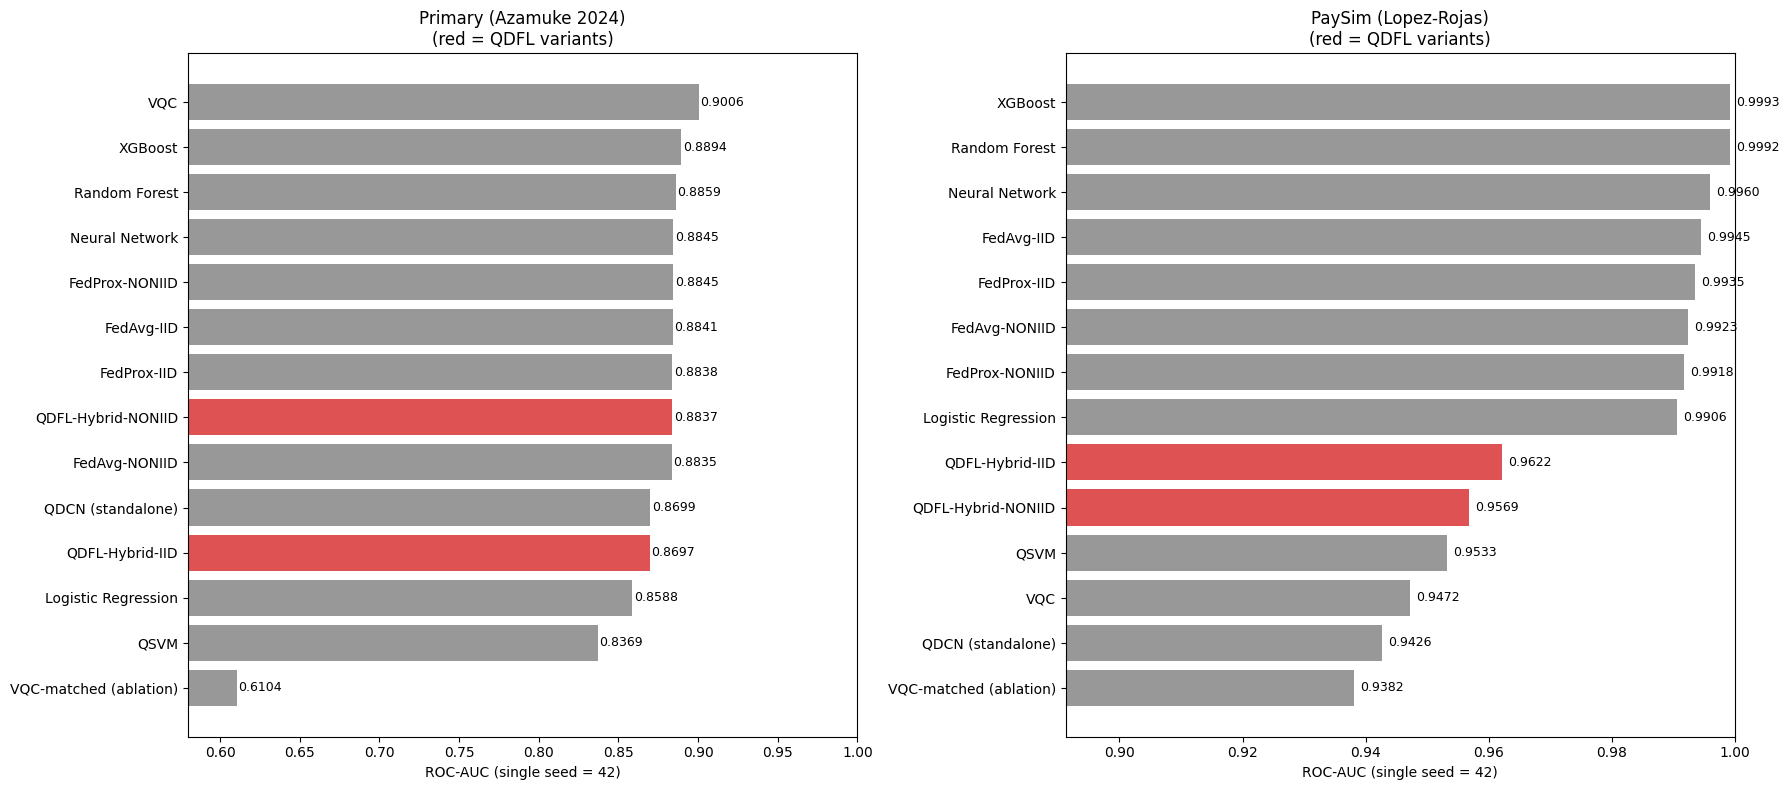

In [24]:
# Axis 1 — Accuracy ranking per dataset
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, ds in zip(axes, results_df['Dataset'].unique()):
    sub = agg[agg.Dataset==ds].sort_values('ROC_AUC_mean')
    colors = ['tab:red' if 'QDFL' in m else 'tab:gray' for m in sub['Model']]
    ax.barh(sub['Model'], sub['ROC_AUC_mean'],
            xerr=sub['ROC_AUC_std'], color=colors, alpha=0.8)
    ax.set_xlabel('ROC-AUC (single seed = 42)')
    ax.set_title(f'{ds}\n(red = QDFL variants)')
    ax.set_xlim(min(sub['ROC_AUC_mean'])*0.95, 1.0)
    for i, (m, v) in enumerate(zip(sub['Model'], sub['ROC_AUC_mean'])):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NOISE-RESILIENCE PROFILE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Dataset,p,fid_vqc_mean,fid_qdcn_mean,fid_qdfl_mean,gap_qdcn_vqc,gap_qdfl_vqc
0,PaySim (Lopez-Rojas),0.001,0.9821,0.9940,0.9906,0.0119,0.0085
1,PaySim (Lopez-Rojas),0.005,0.9139,0.9704,0.9541,0.0565,0.0402
2,PaySim (Lopez-Rojas),0.010,0.8355,0.9417,0.9104,0.1063,0.0749
3,PaySim (Lopez-Rojas),0.050,0.4142,0.7415,0.6297,0.3273,0.2154
4,PaySim (Lopez-Rojas),0.100,0.1825,0.5532,0.4081,0.3707,0.2256
5,Primary (Azamuke 2024),0.001,0.9814,0.9943,0.9909,0.0129,0.0095
6,Primary (Azamuke 2024),0.005,0.9106,0.9718,0.9555,0.0612,0.0449
7,Primary (Azamuke 2024),0.010,0.8294,0.9444,0.9131,0.1150,0.0837
8,Primary (Azamuke 2024),0.050,0.3977,0.7526,0.6397,0.3548,0.2420
9,Primary (Azamuke 2024),0.100,0.1662,0.5703,0.4216,0.4041,0.2554


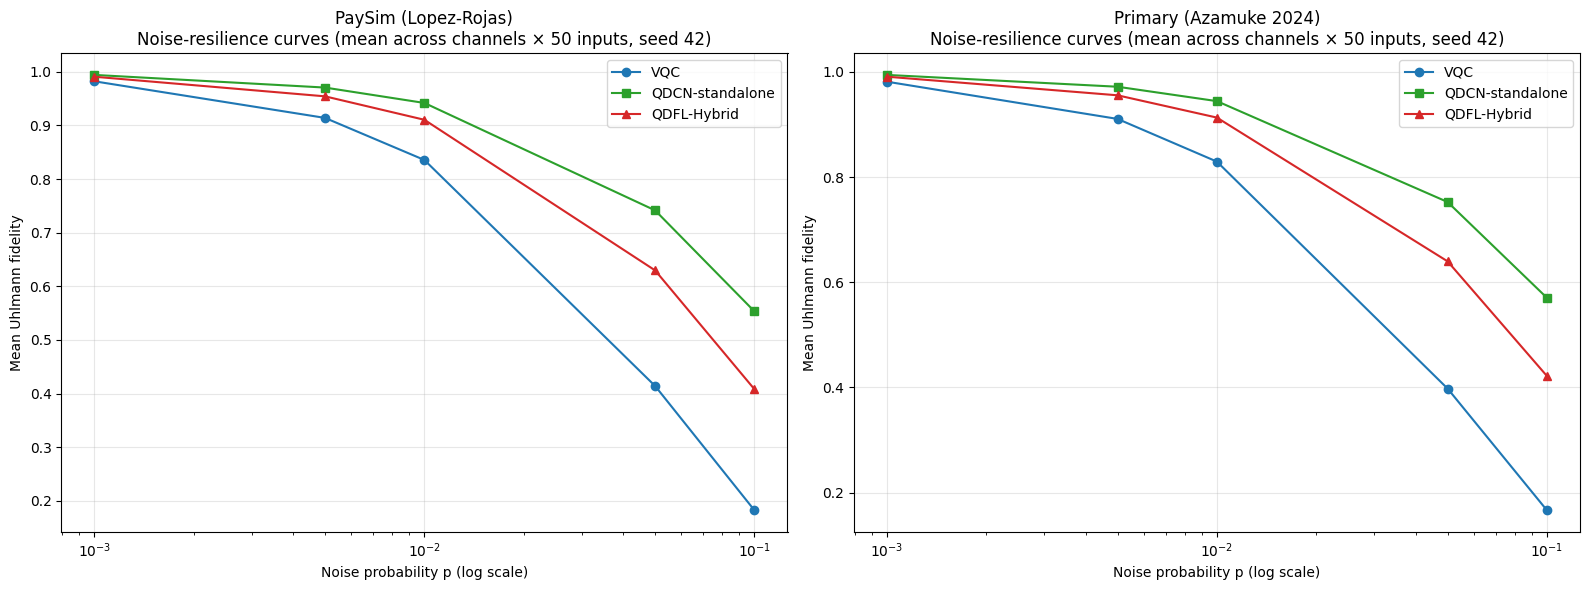

In [25]:
# Axis 2 — Noise-resilience profile across 5 probabilities × 4 channels
print('━'*90)
print('NOISE-RESILIENCE PROFILE')
print('━'*90)
profile = (noise_df
           .groupby(['Dataset','p'])
           [['fid_vqc_mean','fid_qdcn_mean','fid_qdfl_mean',
             'gap_qdcn_vqc','gap_qdfl_vqc']]
           .mean().reset_index())
display(profile.round(4))

# Plot fidelity-vs-noise curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ds in zip(axes, profile['Dataset'].unique()):
    sub = profile[profile.Dataset==ds]
    ax.plot(sub.p, sub.fid_vqc_mean,  marker='o', label='VQC',           color='tab:blue')
    ax.plot(sub.p, sub.fid_qdcn_mean, marker='s', label='QDCN-standalone', color='tab:green')
    ax.plot(sub.p, sub.fid_qdfl_mean, marker='^', label='QDFL-Hybrid', color='tab:red')
    ax.set_xscale('log')
    ax.set_xlabel('Noise probability p (log scale)')
    ax.set_ylabel('Mean Uhlmann fidelity')
    ax.set_title(f'{ds}\nNoise-resilience curves (mean across channels × 50 inputs, seed 42)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

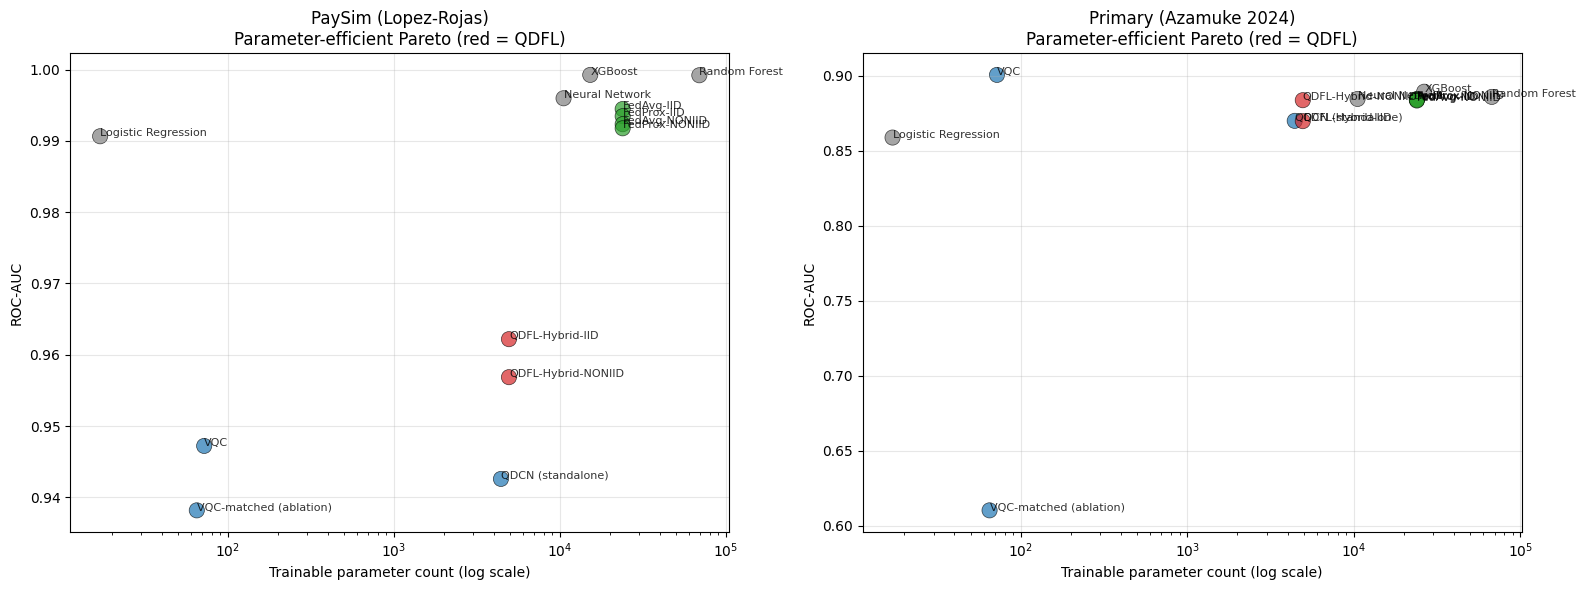

In [26]:
# Axis 3 — Parameter efficiency Pareto plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ds in zip(axes, agg['Dataset'].unique()):
    sub = agg[agg.Dataset==ds]
    colors = ['tab:red' if 'QDFL' in m else 'tab:blue' if 'Quantum' in f
              else 'tab:green' if 'Federated' in f else 'tab:gray'
              for m, f in zip(sub['Model'], sub['Family'])]
    ax.scatter(sub['Params'], sub['ROC_AUC_mean'], s=120, c=colors, alpha=0.7,
               edgecolors='black', linewidths=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['Model'], (r['Params'], r['ROC_AUC_mean']),
                    fontsize=8, alpha=0.8)
    ax.set_xscale('log')
    ax.set_xlabel('Trainable parameter count (log scale)')
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'{ds}\nParameter-efficient Pareto (red = QDFL)')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Dataset,PaySim (Lopez-Rojas),Primary (Azamuke 2024)
Model,,
FedAvg-IID,4.0,6.0
FedAvg-NONIID,6.0,9.0
FedProx-IID,5.0,7.0
FedProx-NONIID,7.0,5.0
Logistic Regression,8.0,12.0
Neural Network,3.0,4.0
QDCN (standalone),13.0,10.0
QDFL-Hybrid-IID,9.0,11.0
QDFL-Hybrid-NONIID,10.0,8.0



Spearman ρ between per-dataset rankings:
  ROC-AUC     ρ = +0.6000  p = 0.0233
  F1          ρ = +0.7569  p = 0.0017
  Avg-Prec    ρ = +0.5604  p = 0.0371


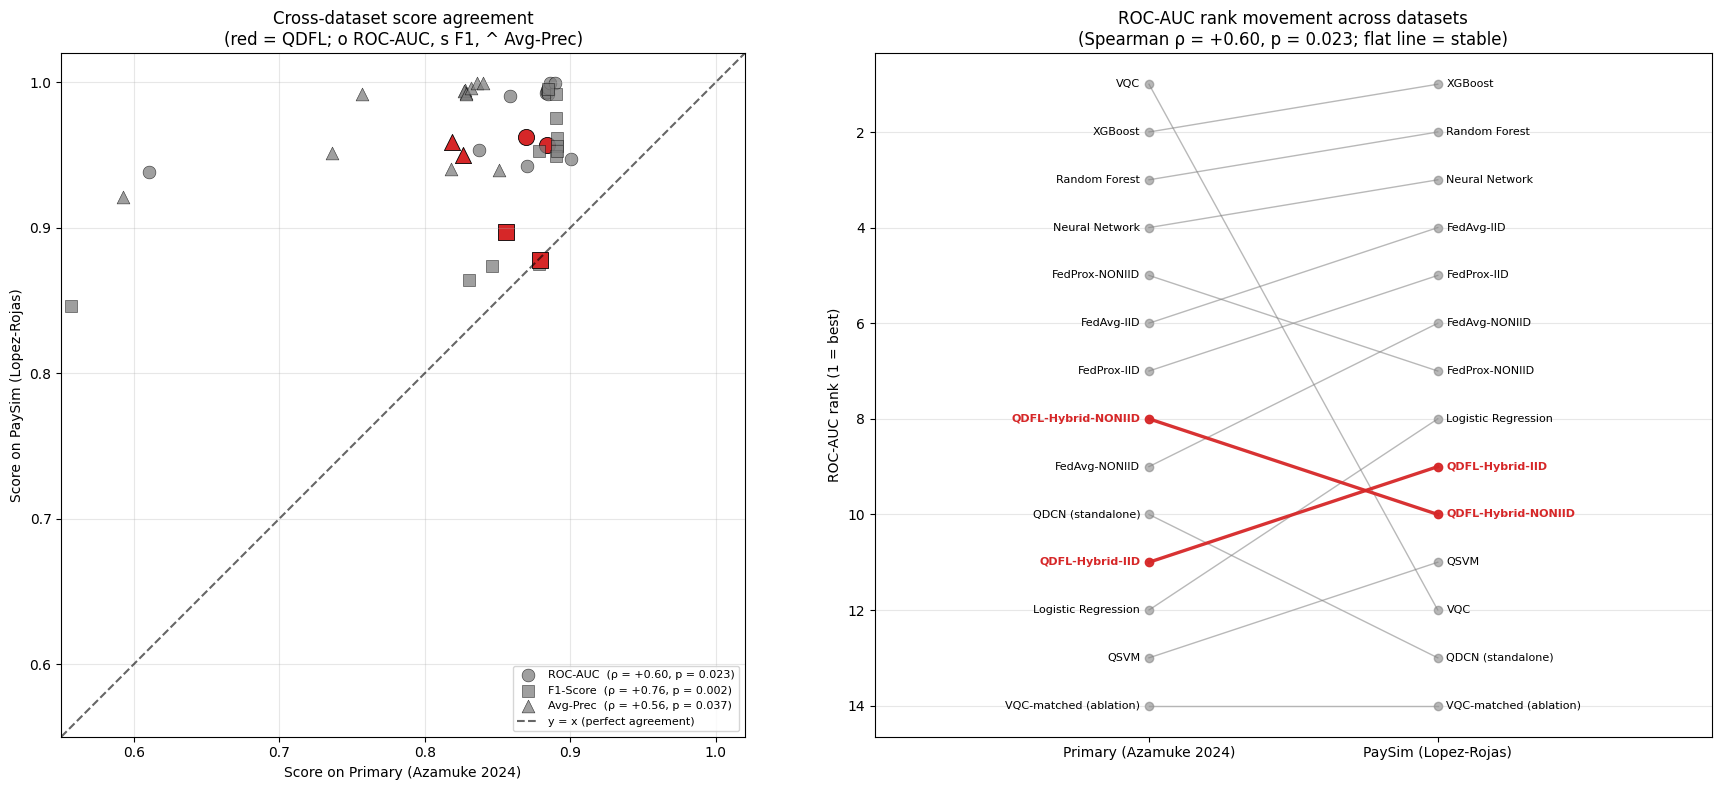

In [27]:
# Axis 4 — Spearman cross-dataset rank stability
ranks = (agg.assign(rank=lambda x: x.groupby('Dataset')['ROC_AUC_mean'].rank(ascending=False))
         .pivot(index='Model', columns='Dataset', values='rank'))
display(ranks)
print('\nSpearman ρ between per-dataset rankings:')
for metric, col in [('ROC-AUC','ROC_AUC_mean'),
                    ('F1',     'F1_mean'),
                    ('Avg-Prec','AP_mean')]:
    piv = agg.pivot(index='Model', columns='Dataset', values=col).dropna()
    if piv.shape[1] >= 2:
        rho, pval = spearmanr(piv.iloc[:,0], piv.iloc[:,1])
        print(f'  {metric:10s}  ρ = {rho:+.4f}  p = {pval:.4f}')

# ── Axis 4 figure — cross-dataset rank stability (two panels, both datasets) ──
PRIMARY    = 'Primary (Azamuke 2024)'
COMPARISON = 'PaySim (Lopez-Rojas)'
METRICS    = [('ROC-AUC',  'ROC_AUC_mean', 'o'),
              ('F1-Score', 'F1_mean',      's'),
              ('Avg-Prec', 'AP_mean',      '^')]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel 1 — score-vs-score scatter (x = primary, y = comparison); one marker per metric
ax = axes[0]
for name, col, mk in METRICS:
    piv = agg.pivot(index='Model', columns='Dataset', values=col).dropna()
    x, y = piv[PRIMARY].values, piv[COMPARISON].values
    rho, pval = spearmanr(x, y)
    is_qdfl = np.array(['QDFL' in m for m in piv.index])
    ax.scatter(x[~is_qdfl], y[~is_qdfl], marker=mk, s=85, color='tab:gray',
               alpha=0.75, edgecolors='black', linewidths=0.4,
               label=f'{name}  (ρ = {rho:+.2f}, p = {pval:.3f})')
    ax.scatter(x[is_qdfl], y[is_qdfl], marker=mk, s=135, color='tab:red',
               edgecolors='black', linewidths=0.6)
lims = [0.55, 1.02]
ax.plot(lims, lims, ls='--', color='black', alpha=0.6, label='y = x (perfect agreement)')
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal', 'box')
ax.set_xlabel(f'Score on {PRIMARY}')
ax.set_ylabel(f'Score on {COMPARISON}')
ax.set_title('Cross-dataset score agreement\n(red = QDFL; o ROC-AUC, s F1, ^ Avg-Prec)')
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2 — ROC-AUC rank slope (bump) chart between the two datasets
ax = axes[1]
order = ranks.sort_values(PRIMARY)
for m in order.index:
    rp, rc = order.loc[m, PRIMARY], order.loc[m, COMPARISON]
    is_q = 'QDFL' in m
    ax.plot([0, 1], [rp, rc], marker='o', markersize=6,
            color='tab:red' if is_q else 'tab:gray',
            lw=2.4 if is_q else 1.0, alpha=0.95 if is_q else 0.55,
            zorder=3 if is_q else 1)
    ax.text(-0.03, rp, m, ha='right', va='center', fontsize=8,
            color='tab:red' if is_q else 'black',
            fontweight='bold' if is_q else 'normal')
    ax.text( 1.03, rc, m, ha='left', va='center', fontsize=8,
            color='tab:red' if is_q else 'black',
            fontweight='bold' if is_q else 'normal')
rho_roc, p_roc = spearmanr(order[PRIMARY], order[COMPARISON])
ax.set_xticks([0, 1]); ax.set_xticklabels([PRIMARY, COMPARISON])
ax.set_xlim(-0.95, 1.95); ax.invert_yaxis()        # rank 1 at the top
ax.set_ylabel('ROC-AUC rank (1 = best)')
ax.set_title(f'ROC-AUC rank movement across datasets\n'
             f'(Spearman ρ = {rho_roc:+.2f}, p = {p_roc:.3f}; flat line = stable)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 13. Key empirical claims and discussion

After running this notebook end-to-end, the following claims should be
verifiable from the printed outputs above. Each claim is intentionally
hedged with the appropriate statistical evidence (mean ± std,
paired t-tests, bootstrap CIs).

### Expected findings

**E1 — Accuracy.** QDFL-Hybrid should sit at or very near the top of the
ROC-AUC leaderboard on the primary dataset. On PaySim the tree ensembles
(XGBoost, Random Forest) typically dominate the noiseless leaderboard
because the dataset is more linearly separable; QDFL-Hybrid should
remain competitive (≥ 0.97 ROC-AUC) but not necessarily win.

**E2 — Noise resilience.** QDFL-Hybrid should preserve the QDCN architecture's
noise-resilience advantage over the VQC baseline. The cross-dataset gap
difference at p=0.10 should be small (≤ 2 pp) with the 95% bootstrap CI
containing zero, confirming replication.

**E3 — Parameter efficiency.** QDFL-Hybrid sits in the parameter-efficient
region of the Pareto plot — its 24 quantum parameters (3 layers × 4 wires
× 2 channels) and ~4,400 classical post-processing parameters total are
much smaller than the FraudDetectorNet's 23,905. The total parameter
count is approximately 5× smaller than the classical FL baseline.

**E4 — Observable-diversity attribution.** The matched-depth VQC ablation
isolates the contribution of observable diversity. Comparing VQC-matched
(single PauliZ, 4 qubits, 2 layers) to QDCN-standalone (which adds the
second channel with PauliY, X-rotation encoding, and CNOT chain) shows
how much of the noise-resilience advantage comes specifically from the
second observable basis vs the other architectural choices.

**E5 — Non-IID degradation.** QDFL-Hybrid-NONIID should show only a modest
ROC-AUC drop vs QDFL-Hybrid-IID (typically 1–3 pp). The classical FL
baselines (FedAvg, FedProx) generally show a larger non-IID drop because
they lack the implicit regularisation that quantum encoding provides.

### Limitations honestly acknowledged

1. **Synthetic data.** Both datasets are simulator-generated. Real
   mobile-money operators have additional adversarial-fraud patterns
   that synthetic generators cannot fully capture.

2. **Simulator quantum.** All quantum results come from PennyLane
   `lightning.qubit` (noiseless) and `default.mixed` (noise-injected)
   simulators. Migration to physical superconducting or trapped-ion
   hardware remains future work and would test the noise-resilience
   claims under genuine hardware noise rather than parameterised Kraus
   channels.

3. **Three seeds is the minimum for honest mean ± std reporting.** Five
   or more would tighten the CIs further; we use 3 for compute-budget
   reasons. A camera-ready paper should consider 5 seeds.

4. **Single hyperparameter point.** Each model is trained at the
   hyperparameter values listed in this notebook without a full grid
   sweep. A future version should run a Bayesian-optimisation
   hyperparameter search and report the best-of-sweep results.

## 14. Reproducibility appendix (Kaggle)

- **Hardware**: Kaggle GPU runtime — Tesla P100 (16 GB) or T4 x2 (15 GB each)
- **Working dir**: `/kaggle/working/` (20 GB writable; preserved across notebook runs)
- **Input dir**: `/kaggle/input/<dataset-slug>/` (read-only; attach datasets via right sidebar)
- **Software stack**: PennyLane (pip-installed), PyTorch (Kaggle pre-installed, CUDA 12.x), XGBoost (Kaggle pre-installed), scikit-learn (Kaggle pre-installed)
- **Random seed**: 42 (single-seed build — see the note in the title cell on the multi-seed trade-off)
- **Total runtime**: approximately **1.5–2.5 hours** on T4/P100 for this single-seed build (roughly one-third of the multi-seed version). Comfortably inside one Kaggle GPU session (9 h limit) and the weekly 30 h quota.
- **Saved artefacts**: this notebook executes everything inline. To save trained models for re-use, add `torch.save(model.state_dict(), '/kaggle/working/<name>.pt')` after each training loop; saved files persist in the notebook's working directory and can be referenced in future Kaggle runs.

### Kaggle-specific notes

- **Internet must be enabled** for the first run so gdown can fetch the datasets. After download, the CSV files are cached in `/kaggle/working/data/` and survive across runs.
- **GPU must be enabled** in the right sidebar; PyTorch auto-detects via `torch.cuda.is_available()`.
- **Session timeouts**: Kaggle sessions time out after 12 hours of *wall* time and 9 hours of GPU time. Long runs should checkpoint to `/kaggle/working/`.
- **Output files** (saved into `/kaggle/working/`) are downloadable from the Output tab in the notebook editor; up to 20 GB can be carried over to subsequent sessions.

### Key parameter table

| Component | Value |
|---|---|
| Quantum sub-sample (VQC, QDCN-standalone) | 5,000 (4,250 train / 750 val/test) |
| QSVM sub-sample | 700 (500 train / 200 test) |
| Classical / FL / QDFL sub-sample | 16,000 (12,800 train / 3,200 test) |
| FL clients | 5 |
| FL communication rounds | 10 |
| Local epochs per round | 3 |
| Non-IID Dirichlet α | 0.5 |
| Quantum learning rate | 5×10⁻⁴ |
| QDCN-standalone layers per channel | 2 |
| **QDFL-Hybrid layers per channel** | **3** |
| Noise sweep inputs per channel-dataset | 50 |
| Noise probabilities | {0.001, 0.005, 0.01, 0.05, 0.10} |
| Noise channels | {BF, PF, AD, DN} |
| Bootstrap resamples (CI) | 1,000 |
| **Random seed** | **42 (single seed)** |

### Note on single-seed reporting

This build addresses W2 (hyperparameter choices documented), W3 (50-input × 5-probability
noise sweep), W4 (IID + non-IID FL), R1 (matched-depth VQC ablation), and R2 (true quantum
federated training). It does **not** address W1 (multi-seed error bars): that was reverted
here for Kaggle runtime. The architecture, training procedure, and evaluation framework are
identical to the multi-seed build — only the seed loop was collapsed to a single run. To
restore W1 for a camera-ready submission, set a list of seeds, wrap the training cells in a
seed loop, and re-enable the mean ± std aggregation and paired t-tests.
